In [ ]:
# ====================================================================
# Three-Class Classification: Drinking, Eating, Not_Drinking
# WITH MULTIPLE RANDOM SEEDS LOOP - FIXED TO MATCH WORKING CODE EXACTLY
# ====================================================================
import pandas as pd
import numpy as np
import tensorflow as tf
from tcn import TCN
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from collections import Counter
from scipy.ndimage import rotate
import os

# ====================================================================
# ALL FUNCTIONS EXACTLY FROM YOUR WORKING Try_classification.ipynb
# ====================================================================

def add_gaussian_noise(sip, noise_level=0.02):
    """Add Gaussian noise - EXACTLY FROM YOUR WORKING NOTEBOOK"""
    max_possible_val = 4000
    std_dev = noise_level * max_possible_val
    noise = np.random.normal(0, std_dev, sip.shape)
    noisy_sip = sip + noise
    return np.clip(noisy_sip, a_min=0.0, a_max=None)

def flip_horizontal(sip):
    """Flip 8x8 frames horizontally - EXACTLY FROM YOUR WORKING NOTEBOOK"""
    flipped = []
    for frame in sip:
        frame_8x8 = frame.reshape(8, 8)
        flipped_frame = np.fliplr(frame_8x8).flatten()
        flipped.append(flipped_frame)
    return np.array(flipped, dtype=np.float32)

def rotate_sip(sip, angle):
    """Rotate all frames in a sip - EXACTLY FROM YOUR WORKING NOTEBOOK"""
    rotated = []
    for frame in sip:
        frame_8x8 = frame.reshape(8, 8)
        rotated_frame = rotate(frame_8x8, angle, reshape=False, order=1, mode='nearest')
        rotated.append(rotated_frame.flatten())
    return np.array(rotated, dtype=np.float32)

def get_rotations(sip, num_rotations=2):
    """Get rotated versions of sip - EXACTLY FROM YOUR WORKING NOTEBOOK"""
    realistic_rotation_angles = [5, 355, 10, 350, 20, 340, 30, 330, 45, 315]
    selected_angles = np.random.choice(realistic_rotation_angles, 
                                     size=min(num_rotations, len(realistic_rotation_angles)), 
                                     replace=False)
    return [rotate_sip(sip, angle) for angle in selected_angles]

def apply_balanced_classification_augmentation(X_sequences, y_sequences, is_original, target_total=2000):
    """Apply balanced augmentation for classification - EXACTLY FROM YOUR WORKING NOTEBOOK"""
    print("Applying balanced classification augmentation...")
    
    X_sequences_array = np.array(X_sequences, dtype=object)
    y_sequences_array = np.array(y_sequences)
    is_original_array = np.array(is_original)
    
    # Get original samples
    original_indices = np.where(is_original_array == True)[0]
    original_X = X_sequences_array[original_indices]
    original_y = y_sequences_array[original_indices]
    
    # Analyze distribution
    class_counts = Counter(original_y)
    max_class_count = max(class_counts.values())
    target_per_class = int(max_class_count * 0.8)
    
    print(f"Target samples per class: {target_per_class}")
    
    # Apply augmentation
    augmented_X = list(original_X)
    augmented_y = list(original_y)
    augmented_is_original = [True] * len(original_X)
    
    for class_label in [0, 1, 2]:
        class_indices = np.where(original_y == class_label)[0]
        current_count = len(class_indices)
        
        if current_count < target_per_class:
            needed = target_per_class - current_count
            
            # Determine augmentation strategy - EXACTLY FROM YOUR WORKING NOTEBOOK
            if class_label == 0:  # Not drinking
                rotations = 1 if needed > 50 else 0
                flips = 1
                noise_copies = 0
            elif class_label == 1:  # Drinking
                rotations = 2 if needed > 100 else 1
                flips = 1
                noise_copies = 0
            else:  # Eating
                rotations = 3 if needed > 20 else 2
                flips = 1
                noise_copies = 1
            
            for idx in class_indices:
                x_orig = original_X[idx]
                
                # Apply rotations
                if rotations > 0:
                    rotations_list = get_rotations(x_orig, rotations)
                    for rotated in rotations_list:
                        augmented_X.append(rotated)
                        augmented_y.append(class_label)
                        augmented_is_original.append(False)
                
                # Apply flips
                if flips > 0:
                    flipped = flip_horizontal(x_orig)
                    augmented_X.append(flipped)
                    augmented_y.append(class_label)
                    augmented_is_original.append(False)
                
                # Apply noise
                for _ in range(noise_copies):
                    noisy = add_gaussian_noise(x_orig)
                    augmented_X.append(noisy)
                    augmented_y.append(class_label)
                    augmented_is_original.append(False)
    
    # Convert back to arrays
    final_X = np.array(augmented_X, dtype=object)
    final_y = np.array(augmented_y)
    final_is_original = np.array(augmented_is_original)
    
    print(f"Augmentation complete: {len(final_X)} total samples")
    final_class_counts = Counter(final_y)
    print(f"Final class distribution: {dict(final_class_counts)}")
    
    return final_X, final_y, final_is_original

def create_balanced_train_test_split(X_sequences, y_sequences, is_original, target_total=2000):
    """Create balanced train/test split - EXACTLY FROM YOUR WORKING NOTEBOOK"""
    print("Creating balanced train/test split...")
    
    X_sequences_array = np.array(X_sequences, dtype=object)
    y_sequences_array = np.array(y_sequences)
    is_original_array = np.array(is_original)
    
    # Get original samples
    original_indices = np.where(is_original_array == True)[0]
    X_original = X_sequences_array[original_indices]
    y_original = y_sequences_array[original_indices]
    
    # Define test percentages per class - EXACTLY FROM YOUR WORKING NOTEBOOK
    test_percentages = {0: 0.2, 1: 0.4, 2: 0.8}
    
    # Split per class
    X_test_list, y_test_list = [], []
    X_trainval_list, y_trainval_list = [], []
    
    for class_label in [0, 1, 2]:
        class_indices = np.where(y_original == class_label)[0]
        class_X = X_original[class_indices]
        class_y = y_original[class_indices]
        
        if len(class_indices) == 0:
            continue
        
        test_size = int(len(class_indices) * test_percentages[class_label])
        test_indices = np.random.choice(len(class_indices), size=test_size, replace=False)
        trainval_indices = np.setdiff1d(np.arange(len(class_indices)), test_indices)
        
        X_test_list.extend(class_X[test_indices])
        y_test_list.extend(class_y[test_indices])
        X_trainval_list.extend(class_X[trainval_indices])
        y_trainval_list.extend(class_y[trainval_indices])
    
    # Convert to arrays
    X_test = np.array(X_test_list, dtype=object)
    y_test = np.array(y_test_list)
    X_trainval = np.array(X_trainval_list, dtype=object)
    y_trainval = np.array(y_trainval_list)
    
    # Apply augmentation to trainval
    X_trainval_aug, y_trainval_aug, _ = apply_balanced_classification_augmentation(
        X_trainval, y_trainval, [True] * len(X_trainval), target_total
    )
    
    # Split trainval into train and validation (80/20)
    train_size = int(0.8 * len(X_trainval_aug))
    train_indices = np.random.choice(len(X_trainval_aug), size=train_size, replace=False)
    val_indices = np.setdiff1d(np.arange(len(X_trainval_aug)), train_indices)
    
    X_train = X_trainval_aug[train_indices]
    y_train = y_trainval_aug[train_indices]
    X_val = X_trainval_aug[val_indices]
    y_val = y_trainval_aug[val_indices]
    
    print(f"Final splits - Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")
    
    return X_train, y_train, X_val, y_val, X_test, y_test

def create_sip_sequences_simple(df):
    """Create sip-based sequences - EXACTLY FROM YOUR WORKING NOTEBOOK"""
    sequences = []
    labels = []
    participant_ids = []
    sip_ids = []
    is_original = []

    seq_keys = ["Participant_ID", "sip_id", "Label"]
    for _, group in df.groupby(seq_keys, sort=False):
        label = group["Three_Class_Label"].iloc[0]
        if pd.isna(label):
            continue
        if group["Label"].iloc[0] == 1 and "dV" in group.columns:
            dV = float(group["dV"].iloc[0])
            if dV == 0.0:
                continue
        feature_cols = [col for col in group.columns if col.startswith('Zone_')]
        sip_data = group[feature_cols].to_numpy(np.float32)
        sequences.append(sip_data)
        labels.append(int(label))
        participant_ids.append(group["Participant_ID"].iloc[0])
        sip_ids.append(group["sip_id"].iloc[0])
        is_original.append(True)

    return sequences, np.array(labels, dtype=np.int32), np.array(participant_ids), np.array(sip_ids), np.array(is_original, dtype=bool)

def filter_drinking_data(df):
    """Filter drinking data - EXACTLY FROM YOUR WORKING NOTEBOOK"""
    filtered_data = []
    
    for _, group in df.groupby(['Participant_ID', 'sip_id', 'Label']):
        label = group['Label'].iloc[0]
        
        # For drinking data, check dV
        if label == 'Drinking' and 'dV' in group.columns:
            dV = float(group['dV'].iloc[0])
            if dV == 0.0:
                continue  # Skip zero dV drinking sips
        
        # Keep all eating and Not_Drinking data
        filtered_data.append(group)
    
    return pd.concat(filtered_data, ignore_index=True)

def map_label_to_three_class_corrected(row):
    """Map labels - EXACTLY FROM YOUR WORKING NOTEBOOK"""
    label = row['Label']
    participant_id = row['Participant_ID']
    
    # Check if this is drinking data (lower participant IDs)
    is_drinking_data = participant_id < 100
    
    if pd.isna(label):
        return np.nan
    
    # Handle string labels (eating data)
    if isinstance(label, str):
        if label == 'Not_Drinking':
            return 0
        elif label == 'Drinking':
            return 1
        elif label == 'Eating':
            return 2
        else:
            return np.nan
    
    # Handle numeric labels (drinking data)
    elif isinstance(label, (int, float)):
        if is_drinking_data:
            # For drinking data: 0=Not_Drinking, 1=Drinking
            if label == 0:
                return 0  # Not_Drinking
            elif label == 1:
                return 1  # Drinking
            else:
                return np.nan
        else:
            # For eating data with numeric labels (shouldn't happen but just in case)
            return np.nan
    
    return np.nan

def normalize_data(X_train, X_val, X_test):
    """Normalize data - EXACTLY FROM YOUR WORKING NOTEBOOK"""
    print("Normalizing data...")
    
    # Column-wise z-score normalization (fit on training only)
    mat_train = np.vstack(X_train)
    mean64 = mat_train.mean(0, keepdims=True)
    std64 = mat_train.std(0, keepdims=True) + 1e-8
    
    norm = lambda seq: (seq - mean64) / std64
    X_train_norm = [norm(s) for s in X_train]
    X_val_norm = [norm(s) for s in X_val]
    X_test_norm = [norm(s) for s in X_test]
    
    return X_train_norm, X_val_norm, X_test_norm

def create_data_pipelines(X_train, y_train, X_val, y_val, X_test, y_test, seed):
    """Create tf.data pipelines - EXACTLY FROM YOUR WORKING NOTEBOOK"""
    print("Creating data pipelines...")
    
    BATCH = 1  # Use batch size 1 for variable length sequences
    
    def generator(xs, ys):
        for x, y in zip(xs, ys):
            yield x, y
    
    # FIXED: Use correct output signature from your working notebook
    output_sig = (
        tf.TensorSpec((None, 64), tf.float32),
        tf.TensorSpec((), tf.float32)  # ← FLOAT32 for labels like in your working notebook
    )
    
    def make_ds(xs, ys, shuffle=True):
        ds = tf.data.Dataset.from_generator(
            lambda: generator(xs, ys),
            output_signature=output_sig
        )
        if shuffle:
            ds = ds.shuffle(len(xs), seed=seed)
        if BATCH == 1:
            return ds.repeat().batch(1)              # RESTORED: .repeat() like your working notebook
        return ds.repeat().padded_batch(             # RESTORED: .repeat() like your working notebook
            BATCH,
            padded_shapes=([None, 64], []),
            padding_values=(0.0, 0.0)
        )
    
    train_ds = make_ds(X_train, y_train, shuffle=True)
    val_ds = make_ds(X_val, y_val, shuffle=False)
    test_ds = make_ds(X_test, y_test, shuffle=False)
    
    print("Data pipelines created successfully!")
    return train_ds, val_ds, test_ds

def create_tcn_model(num_classes=3):
    """Create TCN model - EXACTLY FROM YOUR WORKING NOTEBOOK"""
    print("Creating TCN model...")
    
    inp = tf.keras.Input(shape=(None, 64))
    x = TCN(
        nb_filters=128,
        kernel_size=2,
        dilations=[1, 2, 4, 8, 16, 32],
        dropout_rate=0.1,
        return_sequences=False
    )(inp)
    out = tf.keras.layers.Dense(num_classes, activation="softmax")(x)
    
    model = tf.keras.Model(inp, out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    
    return model

def train_model(model, train_ds, val_ds, X_train, X_val, seed):
    """Train the model - EXACTLY FROM YOUR WORKING NOTEBOOK"""
    print(f"Training model for seed {seed}...")
    
    # Callbacks
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=15, restore_best_weights=True
    )
    
    # Train - EXACTLY FROM YOUR WORKING NOTEBOOK
    history = model.fit(
        train_ds,
        epochs=50,
        steps_per_epoch=len(X_train),
        validation_data=val_ds,
        validation_steps=len(X_val),
        callbacks=[early_stopping],
        verbose=1
    )
    
    return history

def evaluate_model(model, X_test_norm, y_test, seed):
    """Evaluate the trained model - EXACTLY FROM YOUR WORKING NOTEBOOK"""
    print(f"Evaluating model for seed {seed}...")
    
    # Predictions for variable length sequences - EXACTLY FROM YOUR WORKING NOTEBOOK
    y_pred_probs = []
    for seq in X_test_norm:
        pred = model.predict(seq[None, ...], verbose=0)[0]
        y_pred_probs.append(pred)
    
    y_pred_probs = np.array(y_pred_probs)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    # Ensure data types are correct for sklearn metrics - EXACTLY FROM YOUR WORKING NOTEBOOK
    y_test = np.array(y_test, dtype=float)  # ← FLOAT32 like in your working notebook
    y_pred_float = np.array(y_pred, dtype=float)  # ← FLOAT32 for sklearn metrics
    
    # Calculate metrics with proper error handling - EXACTLY FROM YOUR WORKING NOTEBOOK
    accuracy = accuracy_score(y_test, y_pred_float)
    precision = precision_score(y_test, y_pred_float, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred_float, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred_float, average='weighted', zero_division=0)
    
    # Per-class metrics
    class_names = ["Not_Drinking", "Drinking", "Eating"]
    class_precision = precision_score(y_test, y_pred_float, average=None, zero_division=0)
    class_recall = recall_score(y_test, y_pred_float, average=None, zero_division=0)
    class_f1 = f1_score(y_test, y_pred_float, average=None, zero_division=0)
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred_float)
    
    # Print verification and detailed metrics - EXACTLY FROM YOUR WORKING NOTEBOOK
    print(f"  Verification - True labels shape: {y_test.shape}, Pred labels shape: {y_pred_float.shape}")
    print(f"  True labels unique: {np.unique(y_test)}, Pred labels unique: {np.unique(y_pred_float)}")
    print(f"  Calculated F1: {f1:.4f}")
    
    # Print classification report like in your working notebook
    print(f"\n  Classification Report for Seed {seed}:")
    print(classification_report(y_test, y_pred_float, target_names=class_names))
    
    print(f"  Overall Metrics for Seed {seed}:")
    print(f"    Accuracy: {accuracy:.4f}")
    print(f"    Precision: {precision:.4f}")
    print(f"    Recall: {recall:.4f}")
    print(f"    F1-Score: {f1:.4f}")
    
    return {
        'y_pred': y_pred,
        'y_pred_probs': y_pred_probs,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'class_precision': class_precision,
        'class_recall': class_recall,
        'class_f1': class_f1,
        'confusion_matrix': cm,
        'class_names': class_names
    }

# ====================================================================
# MAIN LOOP WITH MULTIPLE RANDOM SEEDS - NOW EXACTLY LIKE YOUR WORKING CODE
# ====================================================================

def run_classification_with_seed(seed, save_results=True):
    """
    Run complete classification pipeline with a specific random seed
    NOW EXACTLY LIKE YOUR WORKING Try_classification.ipynb
    """
    print(f"\n{'='*80}")
    print(f"RUNNING CLASSIFICATION WITH RANDOM SEED: {seed}")
    print(f"{'='*80}")
    
    # Set random seeds for reproducibility
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)
    
    # Enable TensorFlow debugging
    tf.debugging.enable_check_numerics()
    
    try:
        # ====================================================================
        # Load and combine drinking and eating data (sip-based approach)
        # ====================================================================
        print("Loading and combining data...")
        
        # Load drinking data files
        DRINKING_FILES = [
            "previous_dv0_withoutstraw_sipCAdded.xlsx", 
            "previous_dv0_withstraw_sipCAdded.xlsx",
            "dv0_withoutstraw_sipCAdded.xlsx",
            "dv0_withstraw_sipCAdded.xlsx",
        ]

        # Load and combine drinking data
        drinking_dfs = []
        next_offset = 0

        for fp in DRINKING_FILES:
            df = pd.read_excel(fp)
            
            old_min, old_max = df["Participant_ID"].min(), df["Participant_ID"].max()
            print(f"{fp}: original IDs {old_min} … {old_max}")
            
            df["Participant_ID"] += next_offset
            next_offset = df["Participant_ID"].max() + 1
            
            drinking_dfs.append(df)
            print(f"   shifted to {df['Participant_ID'].min()} … {df['Participant_ID'].max()}")

        drinking_combined = pd.concat(drinking_dfs, ignore_index=True)
        print(f"\nDrinking data shape: {drinking_combined.shape}")

        # Load eating data with sip_id
        eating_data = pd.read_excel("eating_sequence_processed.xlsx")
        print(f"Eating data shape: {eating_data.shape}")

        # Shift eating Participant_IDs to avoid conflicts
        eating_offset = drinking_combined['Participant_ID'].max() + 1
        eating_data['Participant_ID'] += eating_offset
        print(f"Eating Participant_IDs shifted to: {eating_data['Participant_ID'].min()} … {eating_data['Participant_ID'].max()}")

        # ====================================================================
        # Prepare combined data for three-class classification (sip-based)
        # ====================================================================
        print("Preparing combined data...")
        
        # Select relevant columns from drinking data
        drinking_features = drinking_combined.iloc[:, 2:66]  # Skip Participant_ID and Label columns
        drinking_features['Participant_ID'] = drinking_combined['Participant_ID']
        drinking_features['Label'] = drinking_combined['Label']
        drinking_features['sip_id'] = drinking_combined['sip_id']
        drinking_features['dV'] = drinking_combined['dV']

        # Remove time column from eating data if it exists
        if 'Time' in eating_data.columns:
            eating_data_no_time = eating_data.drop('Time', axis=1)
        else:
            eating_data_no_time = eating_data

        # Combine drinking and eating data
        all_data = pd.concat([drinking_features, eating_data_no_time], ignore_index=True)
        print(f"\nCombined data shape: {all_data.shape}")

        # Apply the corrected mapping
        all_data['Three_Class_Label'] = all_data.apply(map_label_to_three_class_corrected, axis=1)

        print("\nThree-class label distribution after CORRECTED mapping:")
        print(all_data['Three_Class_Label'].value_counts().sort_index())
        print(f"NaN values remaining: {all_data['Three_Class_Label'].isna().sum()}")

        # Remove rows with NaN labels
        all_data = all_data.dropna(subset=['Three_Class_Label'])
        print(f"\nData shape after removing NaN: {all_data.shape}")

        # ====================================================================
        # Filter drinking data for zero dV (but keep all eating data)
        # ====================================================================
        print("Filtering drinking data for zero dV...")
        all_data_filtered = filter_drinking_data(all_data)
        all_data = all_data_filtered

        # ====================================================================
        # Create sip-based sequences (STANDARD APPROACH)
        # ====================================================================
        print("Creating sip-based sequences...")
        X_sequences, y_sequences, participant_ids, sip_ids, is_original = create_sip_sequences_simple(all_data)
        print(f"Total sequences: {len(X_sequences)}")
        print(f"Label distribution: {np.bincount(y_sequences)}")
        print(f"Unique participants: {len(np.unique(participant_ids))}")

        # Show class distribution
        class_names = ["Not_Drinking", "Drinking", "Eating"]
        print("\nClass distribution:")
        for i, name in enumerate(class_names):
            count = (y_sequences == i).sum()
            print(f"  {name}: {count}")

        # ====================================================================
        # Create balanced train/test split with augmentation
        # ====================================================================
        print("Creating balanced train/test split...")
        X_train, y_train, X_val, y_val, X_test, y_test = create_balanced_train_test_split(
            X_sequences, y_sequences, is_original, target_total=2000
        )

        # ====================================================================
        # Normalize data
        # ====================================================================
        print("Normalizing data...")
        X_train_norm, X_val_norm, X_test_norm = normalize_data(X_train, X_val, X_test)

        print("Data shapes after normalization:")
        print(f"X_train: {len(X_train_norm)} sequences")
        print(f"X_val: {len(X_val_norm)} sequences")
        print(f"X_test: {len(X_test_norm)} sequences")

        # ====================================================================
        # Create tf.data pipelines
        # ====================================================================
        print("Creating data pipelines...")
        train_ds, val_ds, test_ds = create_data_pipelines(
            X_train_norm, y_train, X_val_norm, y_val, X_test_norm, y_test, seed
        )

        # ====================================================================
        # Create and train TCN model
        # ====================================================================
        print("Creating and training TCN model...")
        model = create_tcn_model(num_classes=3)
        model.summary()

        # Train using the EXACT SAME function from your working notebook
        history = train_model(model, train_ds, val_ds, X_train_norm, X_val_norm, seed)

        # ====================================================================
        # Evaluate model
        # ====================================================================
        print("Evaluating model...")
        results = evaluate_model(model, X_test_norm, y_test, seed)

        # ====================================================================
        # Save results
        # ====================================================================
        if save_results:
            # Create results directory for this seed
            results_dir = f"results_seed_{seed}"
            os.makedirs(results_dir, exist_ok=True)
            
            # Save model
            model.save(f'{results_dir}/three_class_tcn_model_seed_{seed}.keras')
            
            # Save predictions and results
            results_df = pd.DataFrame({
                'True_Label': y_test,
                'Predicted_Label': results['y_pred'],
                'True_Class': [results['class_names'][int(i)] for i in y_test],
                'Predicted_Class': [results['class_names'][int(i)] for i in results['y_pred']]
            })
            results_df.to_excel(f'{results_dir}/classification_results_seed_{seed}.xlsx', index=False)
            
            # Save training history
            history_df = pd.DataFrame(history.history)
            history_df.to_excel(f'{results_dir}/training_history_seed_{seed}.xlsx', index=False)
            
            # Save confusion matrix
            cm_df = pd.DataFrame(results['confusion_matrix'], 
                               columns=results['class_names'], 
                               index=results['class_names'])
            cm_df.to_excel(f'{results_dir}/confusion_matrix_seed_{seed}.xlsx')
            
            print(f"Results saved in {results_dir}/")

        # ====================================================================
        # Return results
        # ====================================================================
        results_summary = {
            'seed': seed,
            'accuracy': results['accuracy'],
            'precision': results['precision'],
            'recall': results['recall'],
            'f1': results['f1'],
            'y_pred': results['y_pred'],
            'y_test': y_test,
            'history': history.history,
            'model': model
        }
        
        print(f"\n=== RESULTS FOR SEED {seed} ===")
        print(f"Test Accuracy: {results['accuracy']:.4f}")
        print(f"Test Precision: {results['precision']:.4f}")
        print(f"Test Recall: {results['recall']:.4f}")
        print(f"Test F1-Score: {results['f1']:.4f}")
        
        return results_summary
        
    except Exception as e:
        print(f"Error occurred with seed {seed}: {str(e)}")
        import traceback
        traceback.print_exc()
        return None

# ====================================================================
# RUN MULTIPLE SEEDS
# ====================================================================

def run_multiple_seeds(seeds=[42, 123, 456, 789, 505, 202, 101, 404, 303, 606]):
    """
    Run classification with multiple random seeds and compare results
    """
    print("="*80)
    print("RUNNING CLASSIFICATION WITH MULTIPLE RANDOM SEEDS")
    print("="*80)
    
    all_results = []
    
    for seed in seeds:
        try:
            result = run_classification_with_seed(seed, save_results=True)
            if result is not None:
                all_results.append(result)
        except Exception as e:
            print(f"Failed to run seed {seed}: {str(e)}")
            continue
    
    # ====================================================================
    # Compare results across seeds
    # ====================================================================
    if len(all_results) > 1:
        print("\n" + "="*80)
        print("COMPARING RESULTS ACROSS SEEDS")
        print("="*80)
        
        # Create comparison DataFrame
        comparison_data = []
        for result in all_results:
            comparison_data.append({
                'Seed': result['seed'],
                'Accuracy': result['accuracy'],
                'Precision': result['precision'],
                'Recall': result['recall'],
                'F1-Score': result['f1']
            })
        
        comparison_df = pd.DataFrame(comparison_data)
        print("\nResults Comparison:")
        print(comparison_df)
        
        # Save comparison
        comparison_df.to_excel('results_comparison_all_seeds.xlsx', index=False)
        print("\nComparison saved to 'results_comparison_all_seeds.xlsx'")
        
        # Find best performing seed
        best_idx = comparison_df['F1-Score'].idxmax()
        best_seed = comparison_df.loc[best_idx, 'Seed']
        best_f1 = comparison_df.loc[best_idx, 'F1-Score']
        
        print(f"\nBest performing seed: {best_seed} (F1-Score: {best_f1:.4f})")
        
        # Statistical summary
        print(f"\nStatistical Summary:")
        print(f"Mean Accuracy: {comparison_df['Accuracy'].mean():.4f} ± {comparison_df['Accuracy'].std():.4f}")
        print(f"Mean Precision: {comparison_df['Precision'].mean():.4f} ± {comparison_df['Precision'].std():.4f}")
        print(f"Mean Recall: {comparison_df['Recall'].mean():.4f} ± {comparison_df['Recall'].std():.4f}")
        print(f"Mean F1-Score: {comparison_df['F1-Score'].mean():.4f} ± {comparison_df['F1-Score'].std():.4f}")
    
    return all_results

# ====================================================================
# MAIN EXECUTION
# ====================================================================

if __name__ == "__main__":
    # Define seeds to try
    seeds_to_try = [42, 123, 456, 789, 505, 202, 101, 404, 303, 606]
    
    print("Available seeds:", seeds_to_try)
    print("You can modify the seeds_to_try list to include different random seeds")
    
    # Run with multiple seeds
    results = run_multiple_seeds(seeds_to_try)
    
    print(f"\nCompleted {len(results)} successful runs out of {len(seeds_to_try)} attempted seeds")
    print("Check the results directories for detailed outputs from each seed") 
    

Available seeds: [42, 123, 456, 789, 505, 202, 101, 404, 303, 606]
You can modify the seeds_to_try list to include different random seeds
RUNNING CLASSIFICATION WITH MULTIPLE RANDOM SEEDS

RUNNING CLASSIFICATION WITH RANDOM SEED: 42
INFO:tensorflow:Enabled check-numerics callback in thread MainThread
Loading and combining data...
previous_dv0_withoutstraw_sipCAdded.xlsx: original IDs 6 … 62
   shifted to 6 … 62
previous_dv0_withstraw_sipCAdded.xlsx: original IDs 9 … 59
   shifted to 72 … 122
dv0_withoutstraw_sipCAdded.xlsx: original IDs 1 … 14
   shifted to 124 … 137
dv0_withstraw_sipCAdded.xlsx: original IDs 1 … 5
   shifted to 139 … 143

Drinking data shape: (134974, 82)
Eating data shape: (25872, 68)
Eating Participant_IDs shifted to: 145 … 170
Preparing combined data...

Combined data shape: (160846, 68)

Three-class label distribution after CORRECTED mapping:
Three_Class_Label
0.0    106987
1.0      6572
2.0      1610
Name: count, dtype: int64
NaN values remaining: 45677

Data sha

Model: "functional_40"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_40 (InputLayer)     │ (None, None, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn_40 (TCN)                    │ (None, 128)            │       386,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 387,075 (1.48 MB)

 Trainable params: 387,075 (1.48 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_49 (InputLayer)     │ (None, None, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn_49 (TCN)                    │ (None, 128)            │       386,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 387,075 (1.48 MB)

 Trainable params: 387,075 (1.48 MB)

 Non-trainable params: 0 (0.00 B)

Training model for seed 606...
Epoch 1/50
1312/1312 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8594 - loss: 2.0463 - val_accuracy: 0.8902 - val_loss: 0.5715
Epoch 2/50
1312/1312 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9262 - loss: 0.3083 - val_accuracy: 0.9421 - val_loss: 0.3397
Epoch 3/50
1312/1312 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9554 - loss: 0.1672 - val_accuracy: 0.9329 - val_loss: 0.2035
Epoch 4/50
1312/1312 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9539 - loss: 0.1862 - val_accuracy: 0.9573 - val_loss: 0.1550
Epoch 5/50
1312/1312 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.9614 - loss: 0.1185 - val_accuracy: 0.9299 - val_loss: 0.6575
Epoch 6/50
1312/1312 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9252 - loss: 0.2904 - val_accuracy: 0.9390 - val_loss: 0.2036
Epoch 7/50
1312/1312 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9709 - loss: 0.1387 - val_accuracy: 0.8994 - val_loss: 0.7284
Epoch 8/50
1312/1312 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step

🔍 Starting confusion matrix analysis for all seeds...
✅ Found 16 seed directories:
   - results_seed_42
   - results_seed_101
   - results_seed_123
   - results_seed_202
   - results_seed_303
   - results_seed_404
   - results_seed_456
   - results_seed_505
   - results_seed_606
   - results_seed_789
   - results_seed_101112
   - results_seed_131415
   - results_seed_161718
   - results_seed_192021
   - results_seed_222324
   - results_seed_252627
📁 Plots will be saved to: /Users/alireza.mohammadshafie/Documents/hydrocare/labeled/Add_Eating/July/confusion_matrix_plots
✅ Loaded results for seed 42: F1 = 0.9207
✅ Loaded results for seed 101: F1 = 0.9489
✅ Loaded results for seed 123: F1 = 0.9344
✅ Loaded results for seed 202: F1 = 0.9090
✅ Loaded results for seed 303: F1 = 0.9348
✅ Loaded results for seed 404: F1 = 0.9300
✅ Loaded results for seed 456: F1 = 0.8968
✅ Loaded results for seed 505: F1 = 0.9017
✅ Loaded results for seed 606: F1 = 0.9394
✅ Loaded results for seed 789: F1 = 0.9

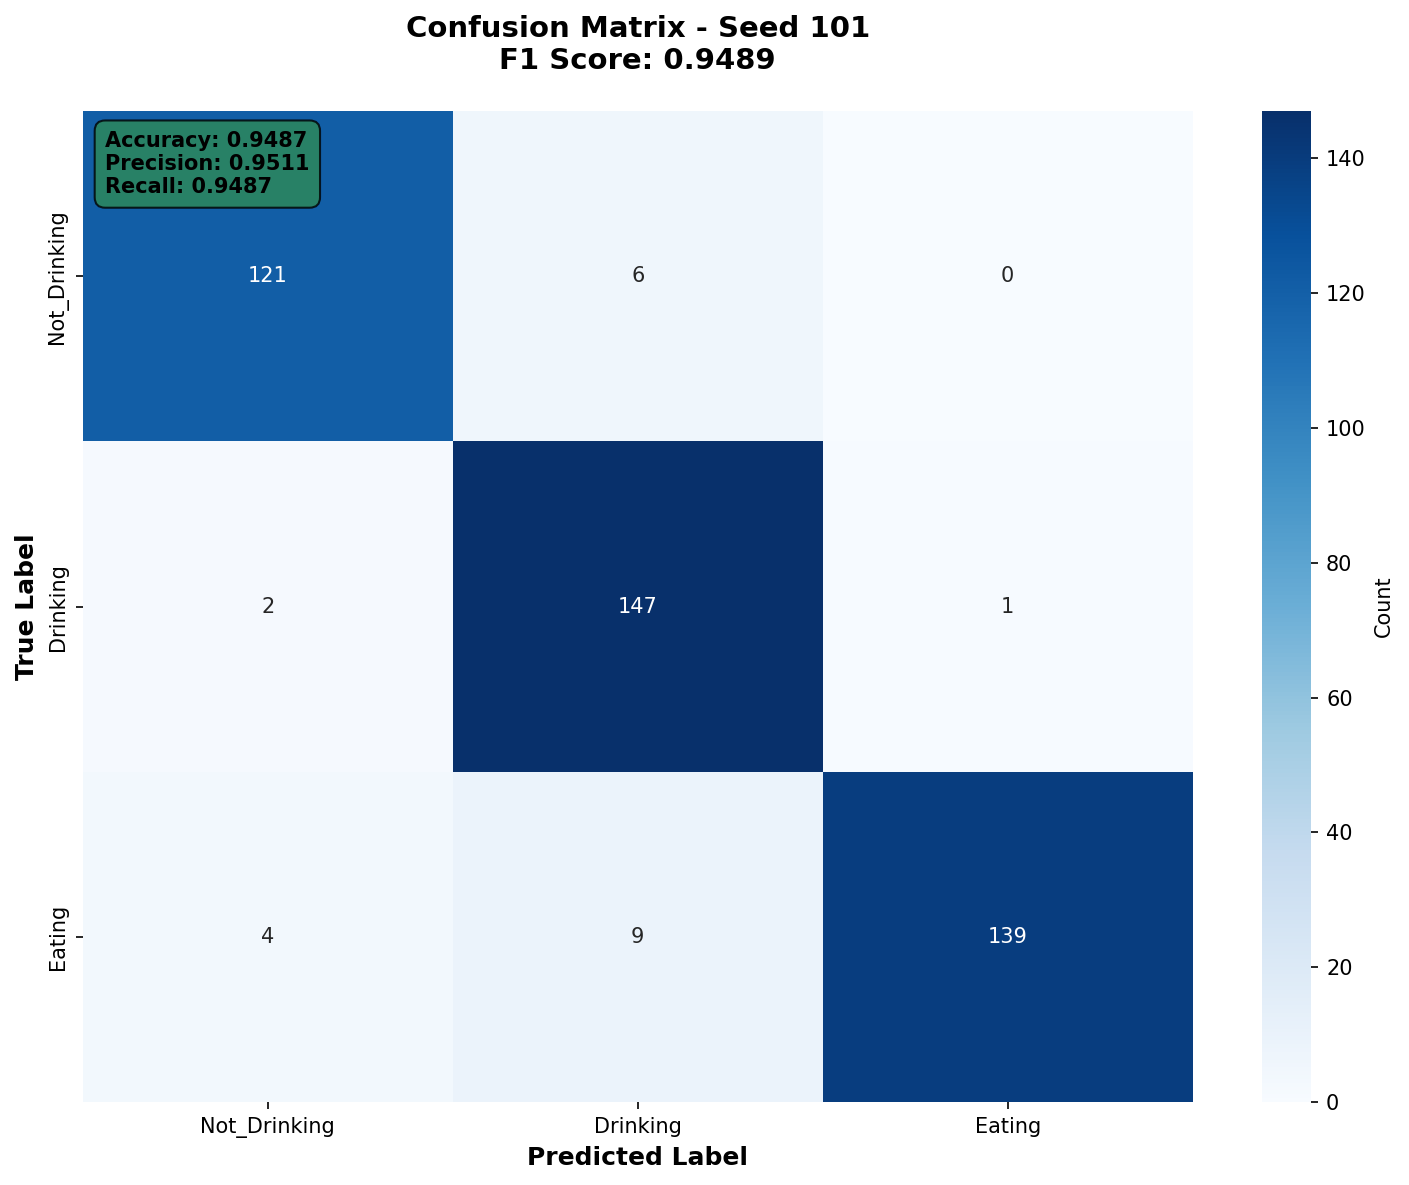

✅ Confusion matrix saved for seed 101
   📷 PNG: confusion_matrix_plots/confusion_matrix_seed_101.png
   📄 PDF: confusion_matrix_plots/confusion_matrix_seed_101.pdf
   📊 Plotting seed 252627 (2/16)


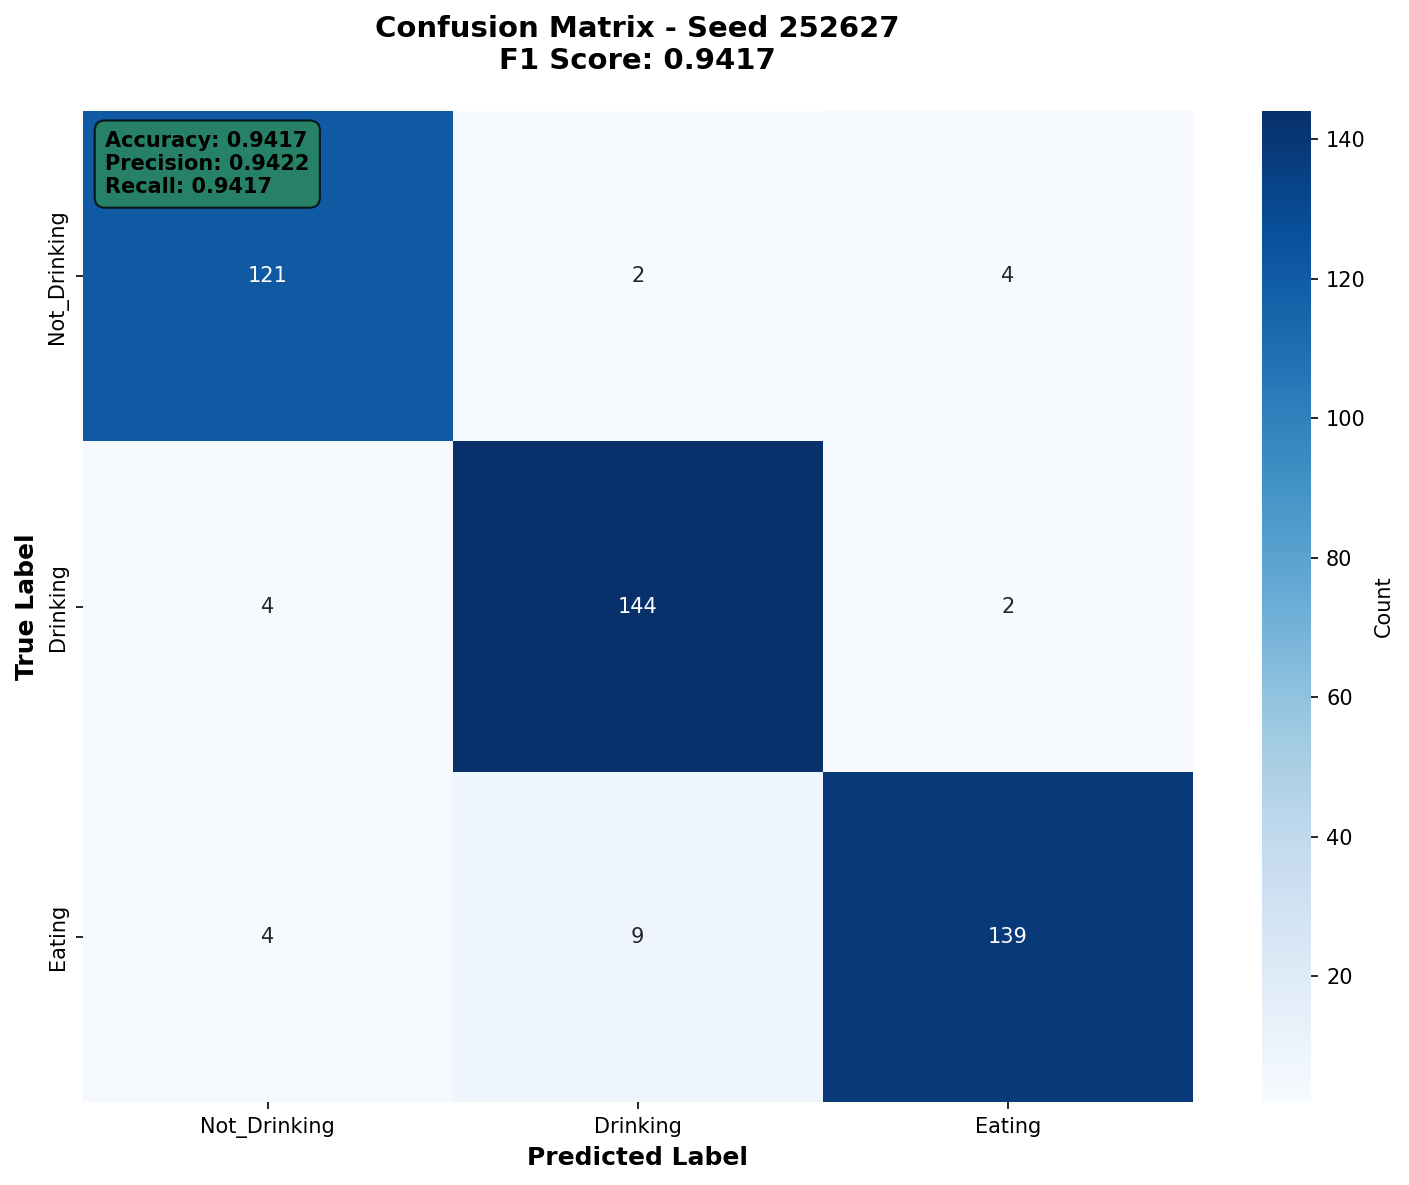

✅ Confusion matrix saved for seed 252627
   📷 PNG: confusion_matrix_plots/confusion_matrix_seed_252627.png
   📄 PDF: confusion_matrix_plots/confusion_matrix_seed_252627.pdf
   📊 Plotting seed 606 (3/16)


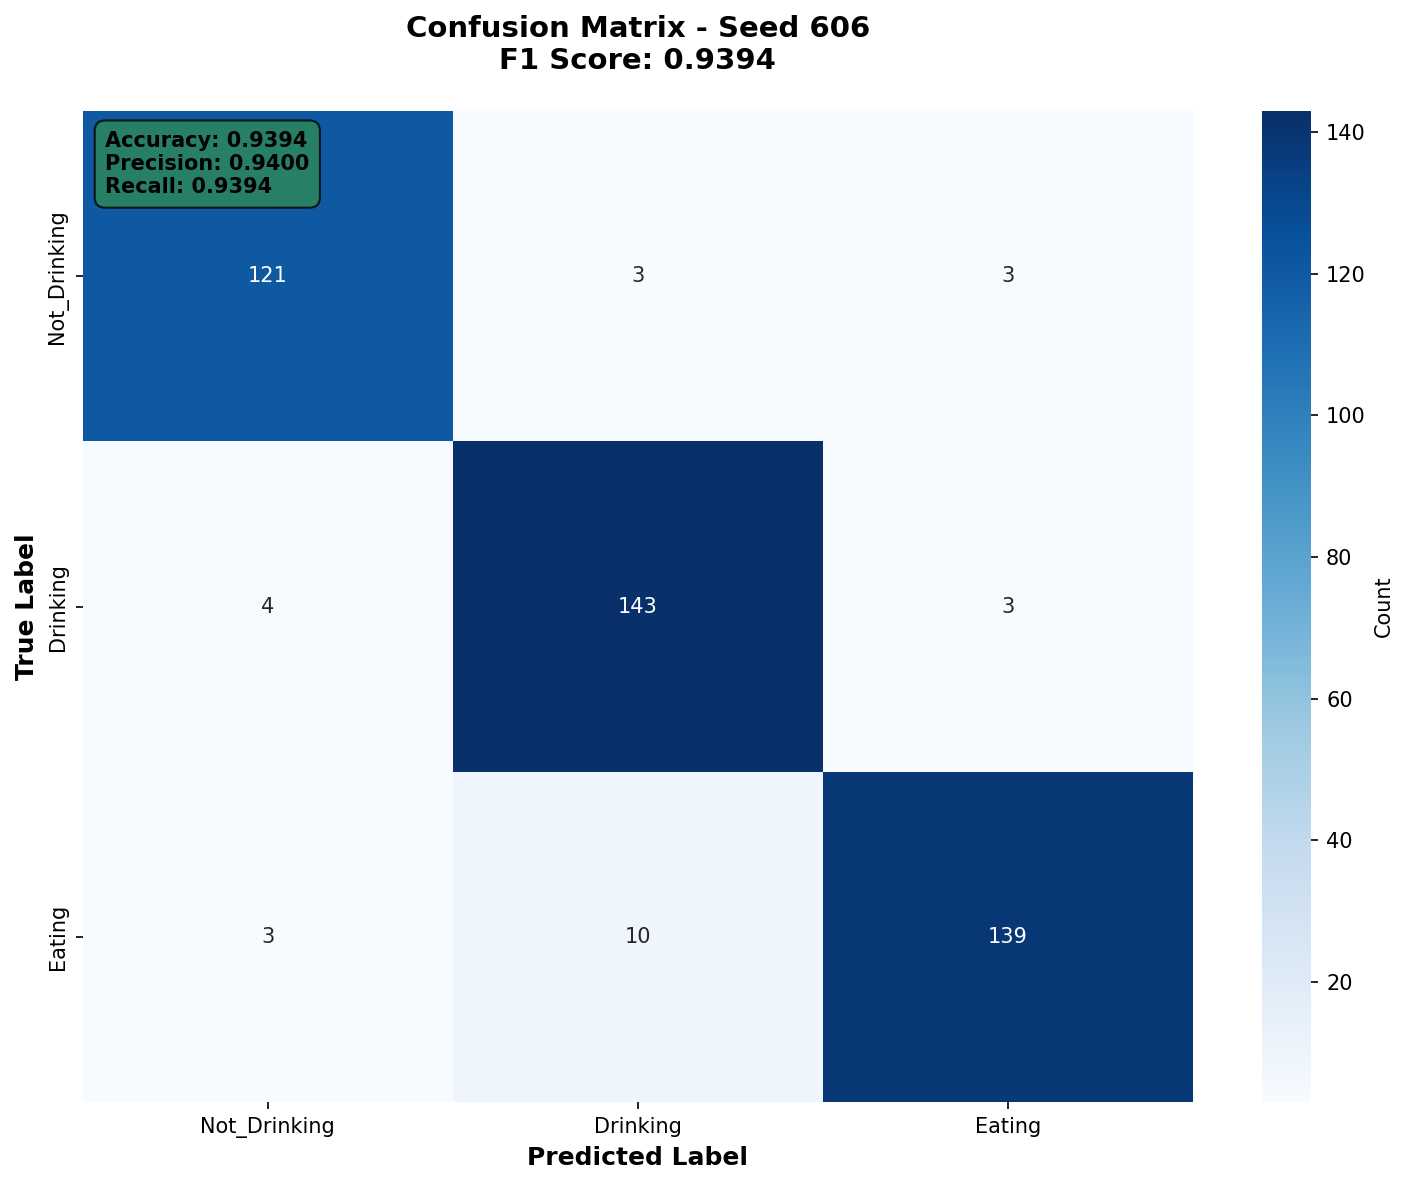

✅ Confusion matrix saved for seed 606
   📷 PNG: confusion_matrix_plots/confusion_matrix_seed_606.png
   📄 PDF: confusion_matrix_plots/confusion_matrix_seed_606.pdf
   📊 Plotting seed 161718 (4/16)


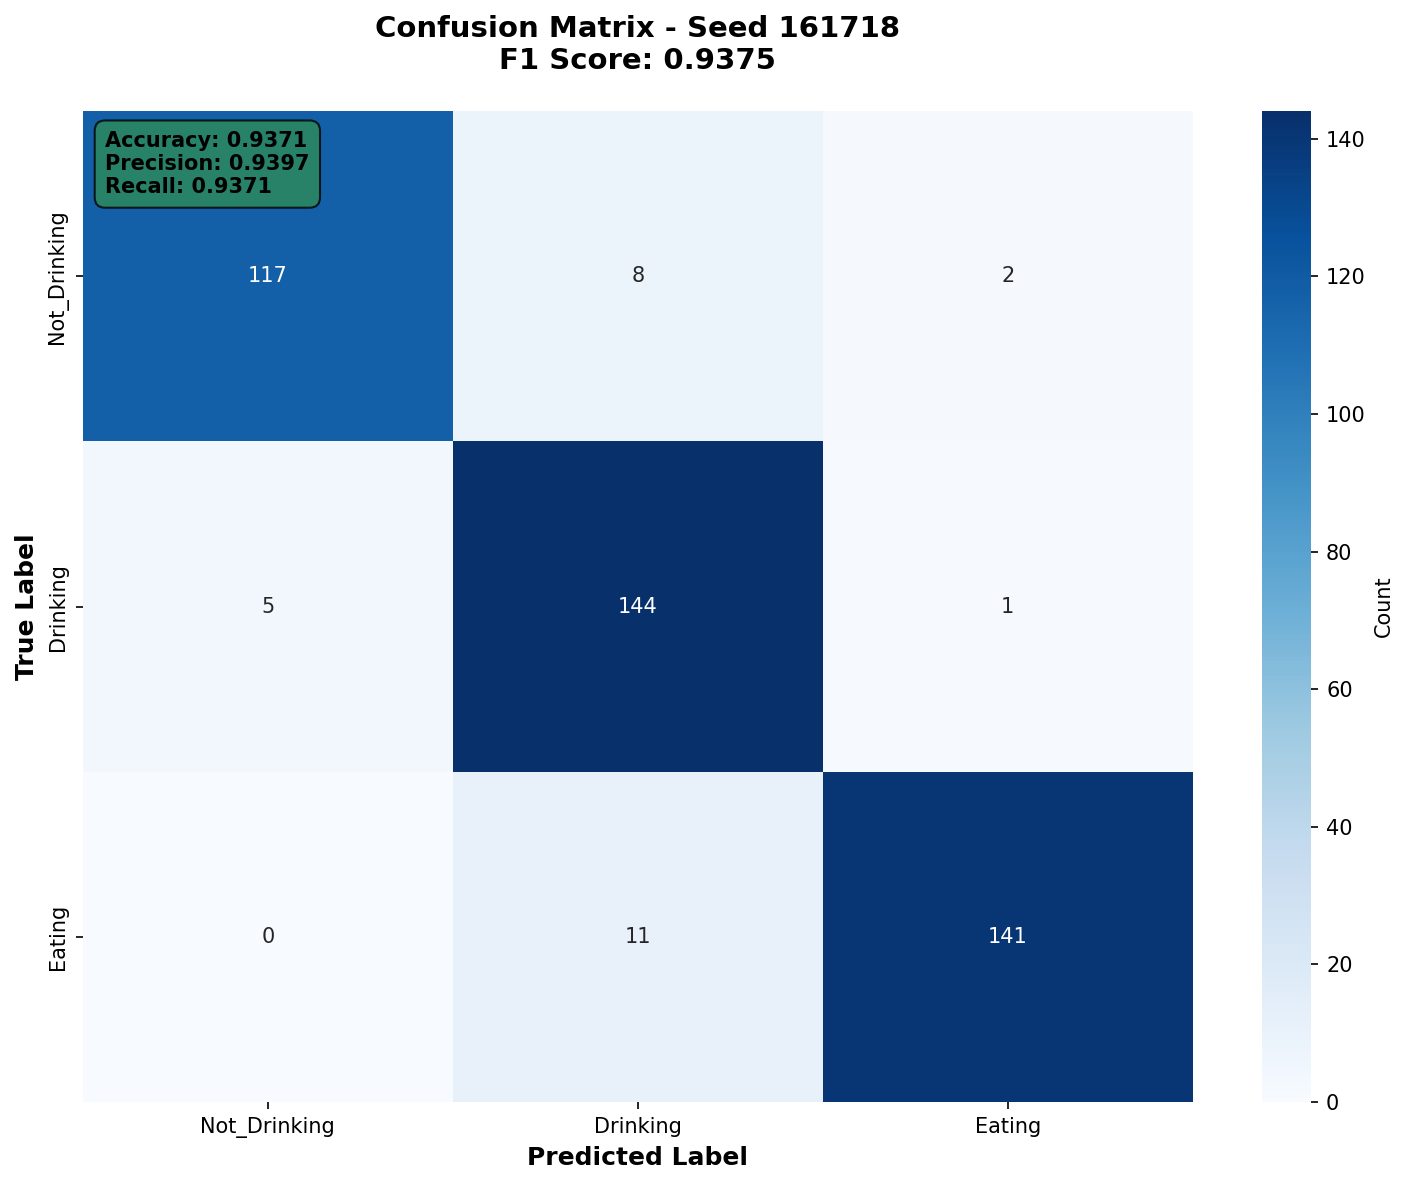

✅ Confusion matrix saved for seed 161718
   📷 PNG: confusion_matrix_plots/confusion_matrix_seed_161718.png
   📄 PDF: confusion_matrix_plots/confusion_matrix_seed_161718.pdf
   📊 Plotting seed 303 (5/16)


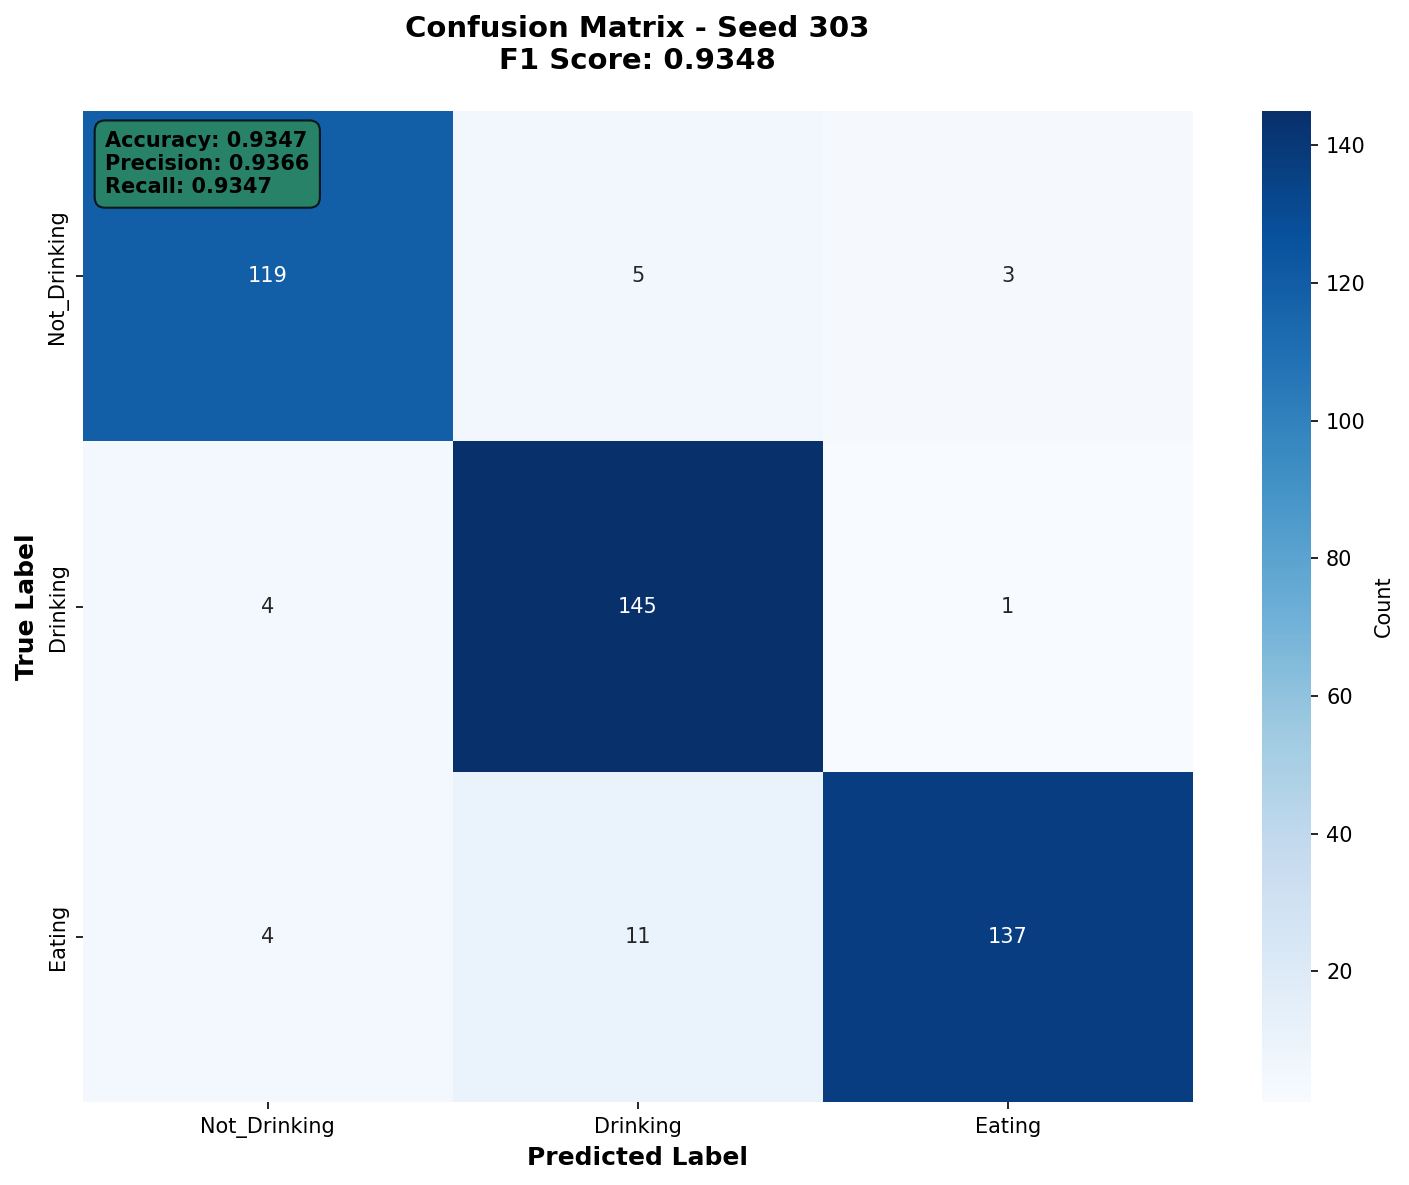

✅ Confusion matrix saved for seed 303
   📷 PNG: confusion_matrix_plots/confusion_matrix_seed_303.png
   📄 PDF: confusion_matrix_plots/confusion_matrix_seed_303.pdf
   📊 Plotting seed 123 (6/16)


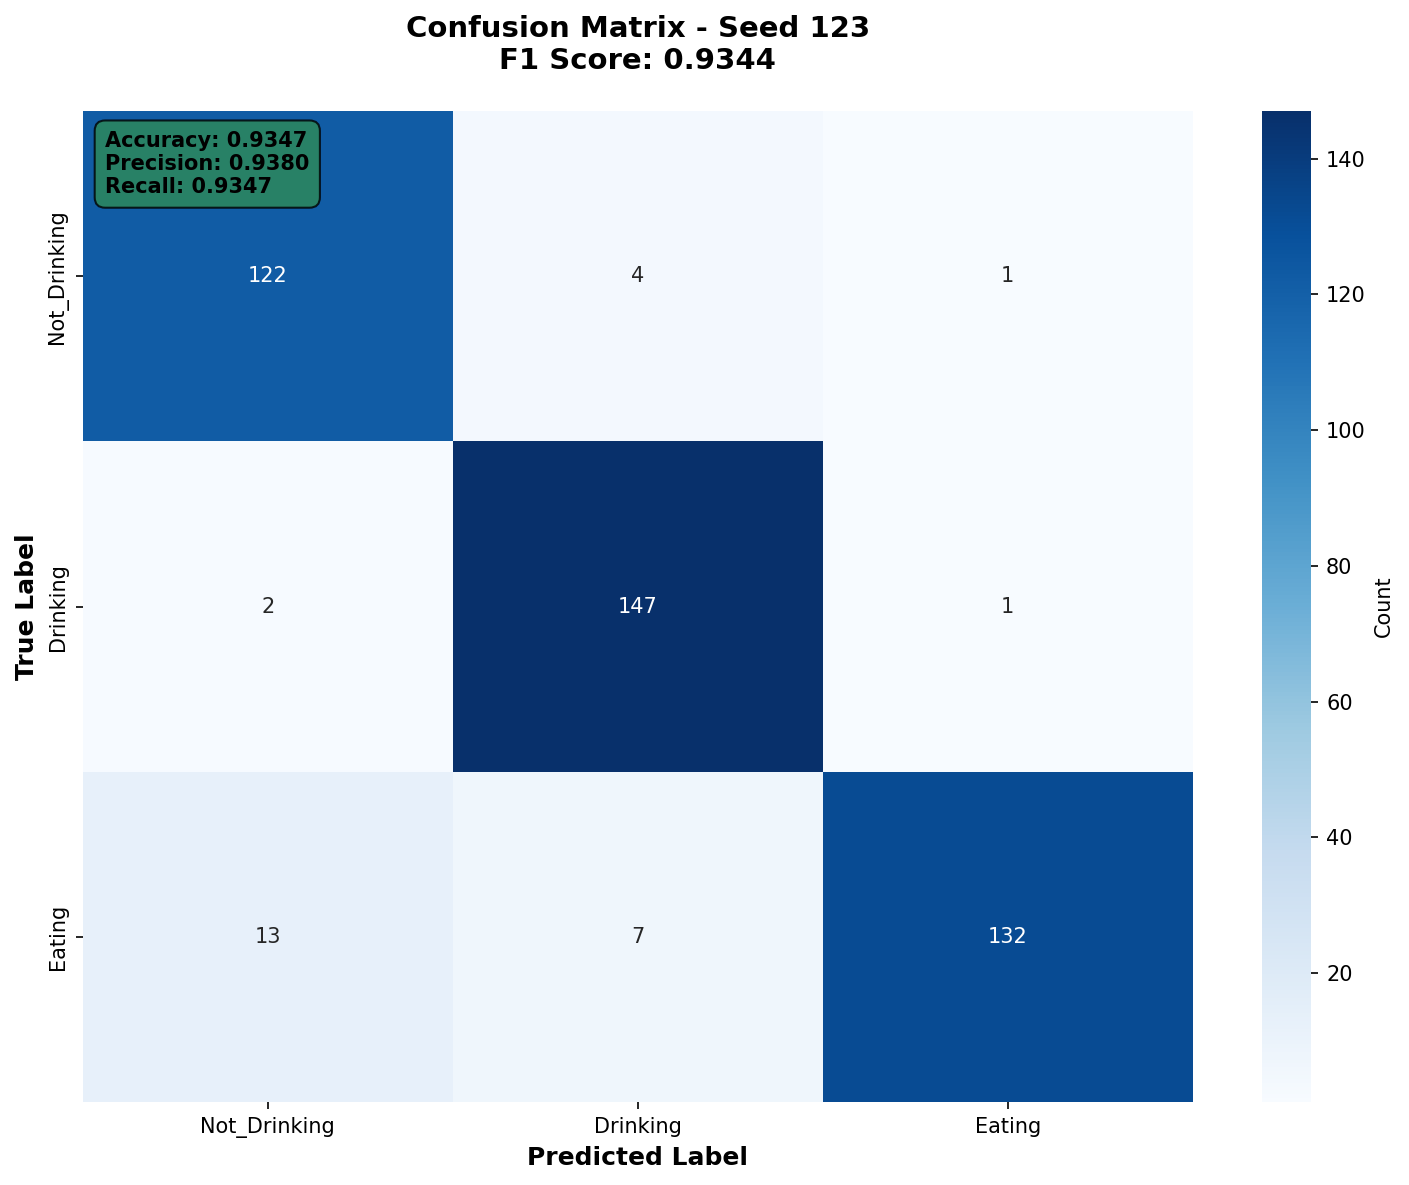

✅ Confusion matrix saved for seed 123
   📷 PNG: confusion_matrix_plots/confusion_matrix_seed_123.png
   📄 PDF: confusion_matrix_plots/confusion_matrix_seed_123.pdf
   📊 Plotting seed 404 (7/16)


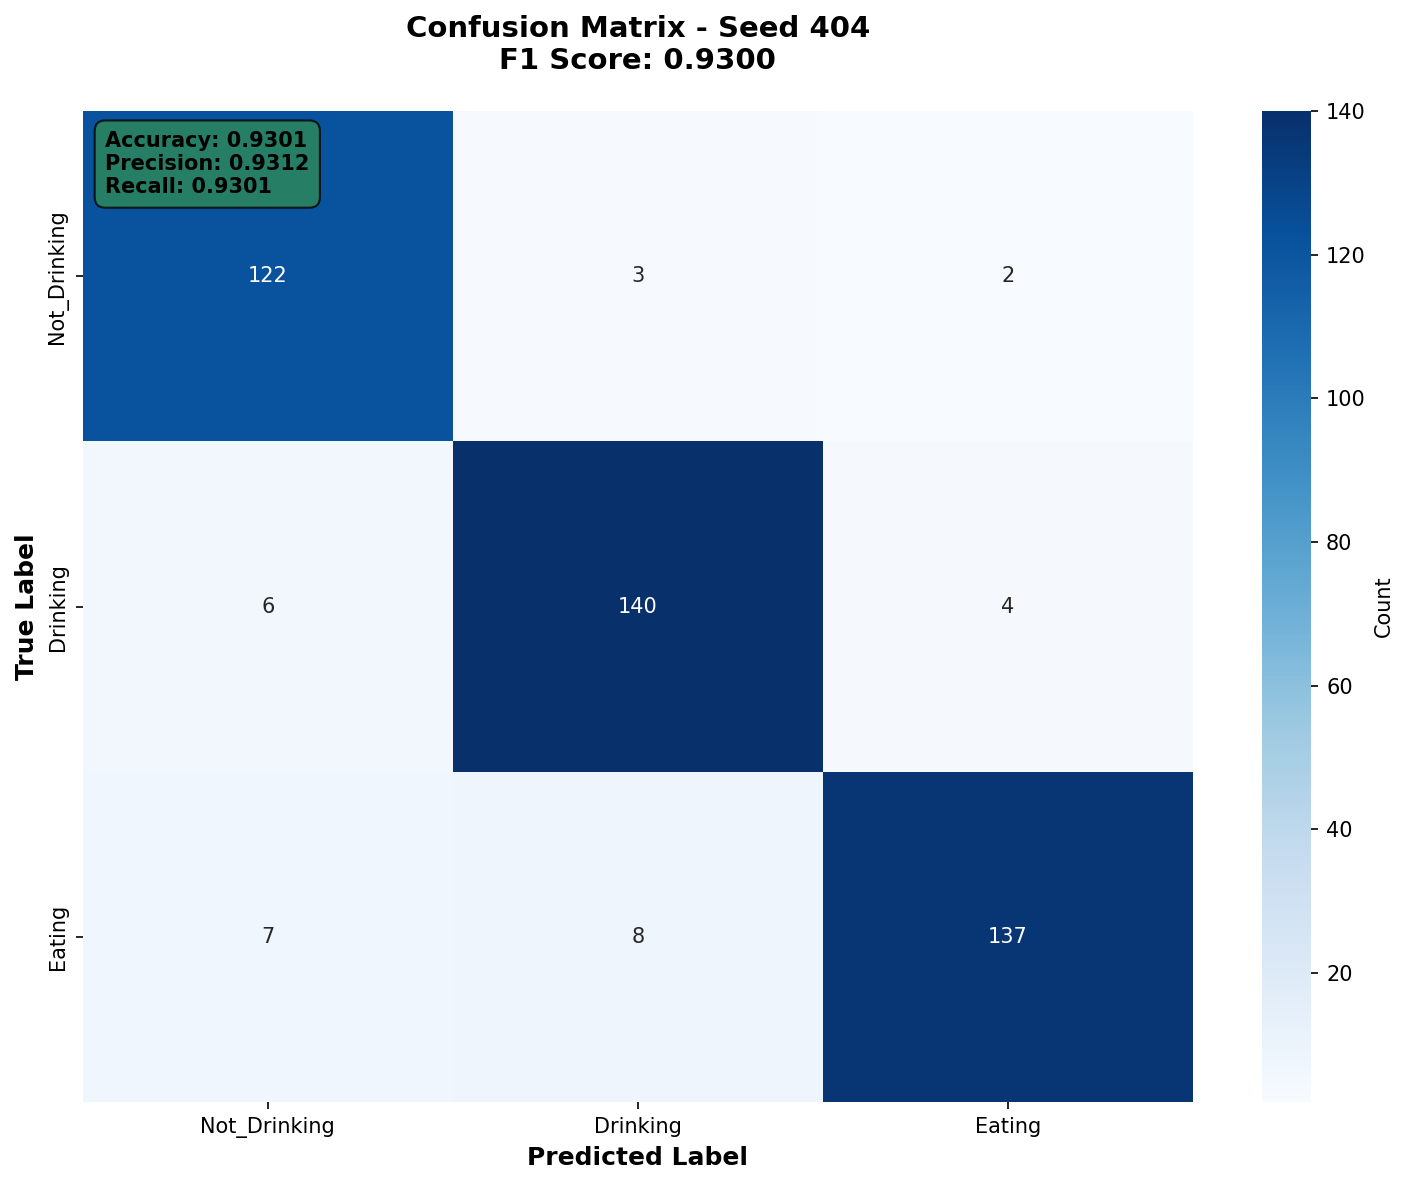

✅ Confusion matrix saved for seed 404
   📷 PNG: confusion_matrix_plots/confusion_matrix_seed_404.png
   📄 PDF: confusion_matrix_plots/confusion_matrix_seed_404.pdf
   📊 Plotting seed 101112 (8/16)


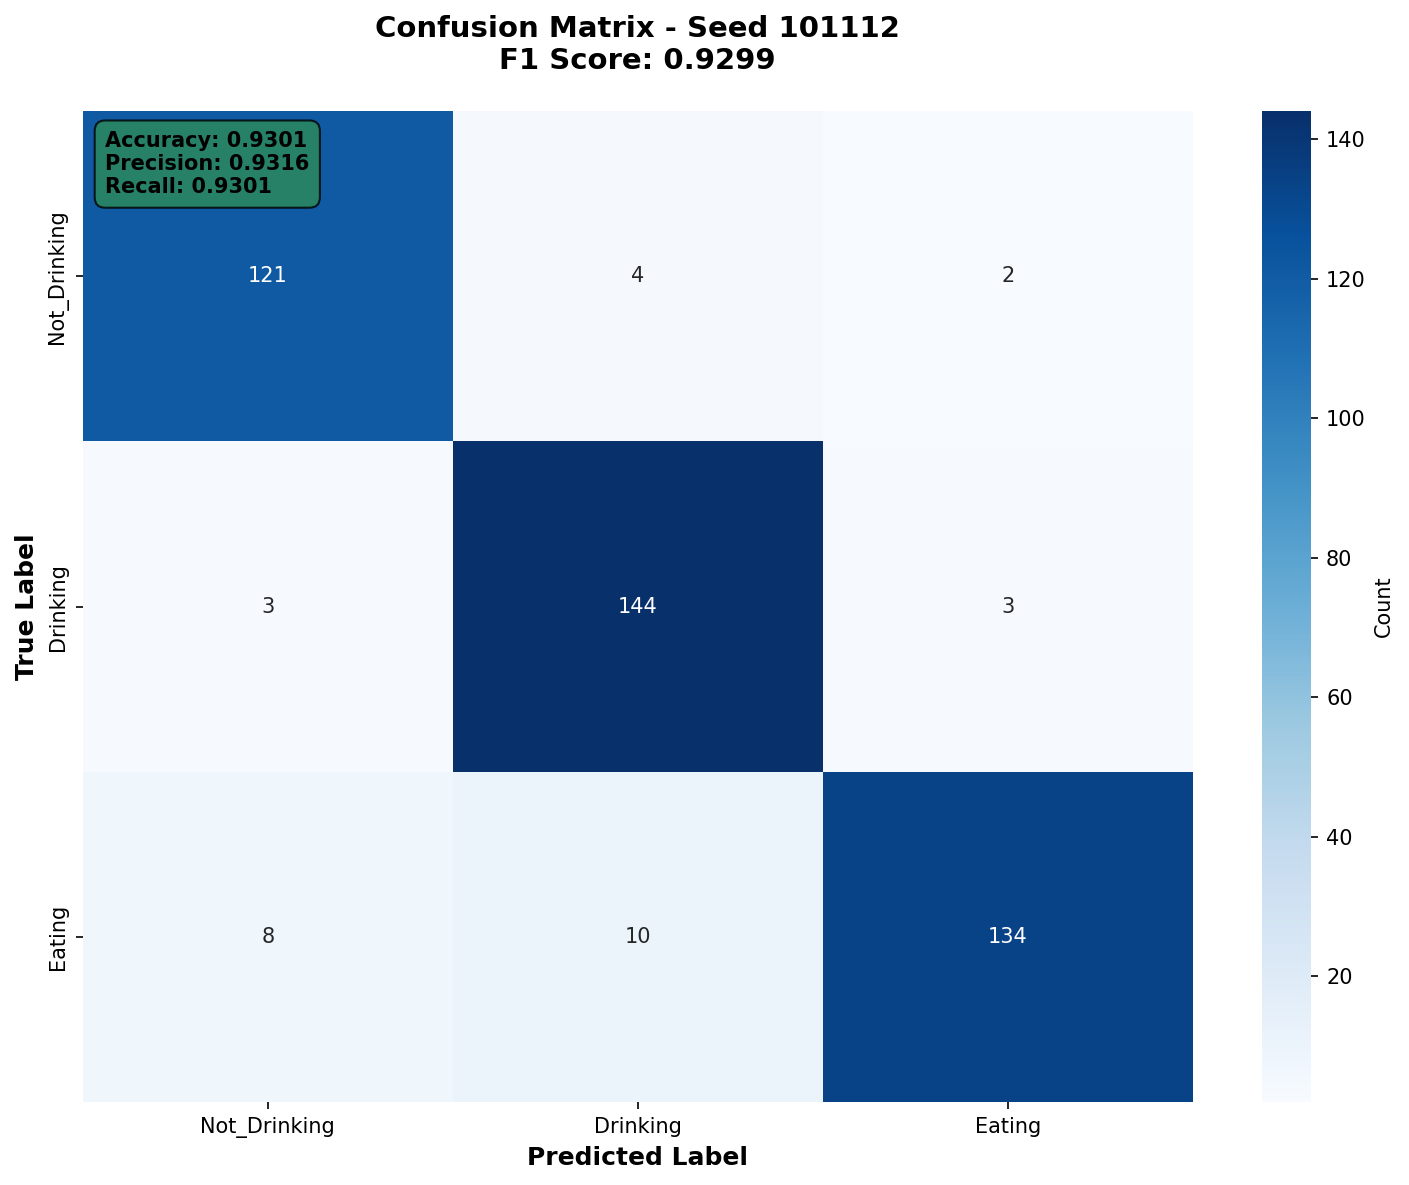

✅ Confusion matrix saved for seed 101112
   📷 PNG: confusion_matrix_plots/confusion_matrix_seed_101112.png
   📄 PDF: confusion_matrix_plots/confusion_matrix_seed_101112.pdf
   📊 Plotting seed 42 (9/16)


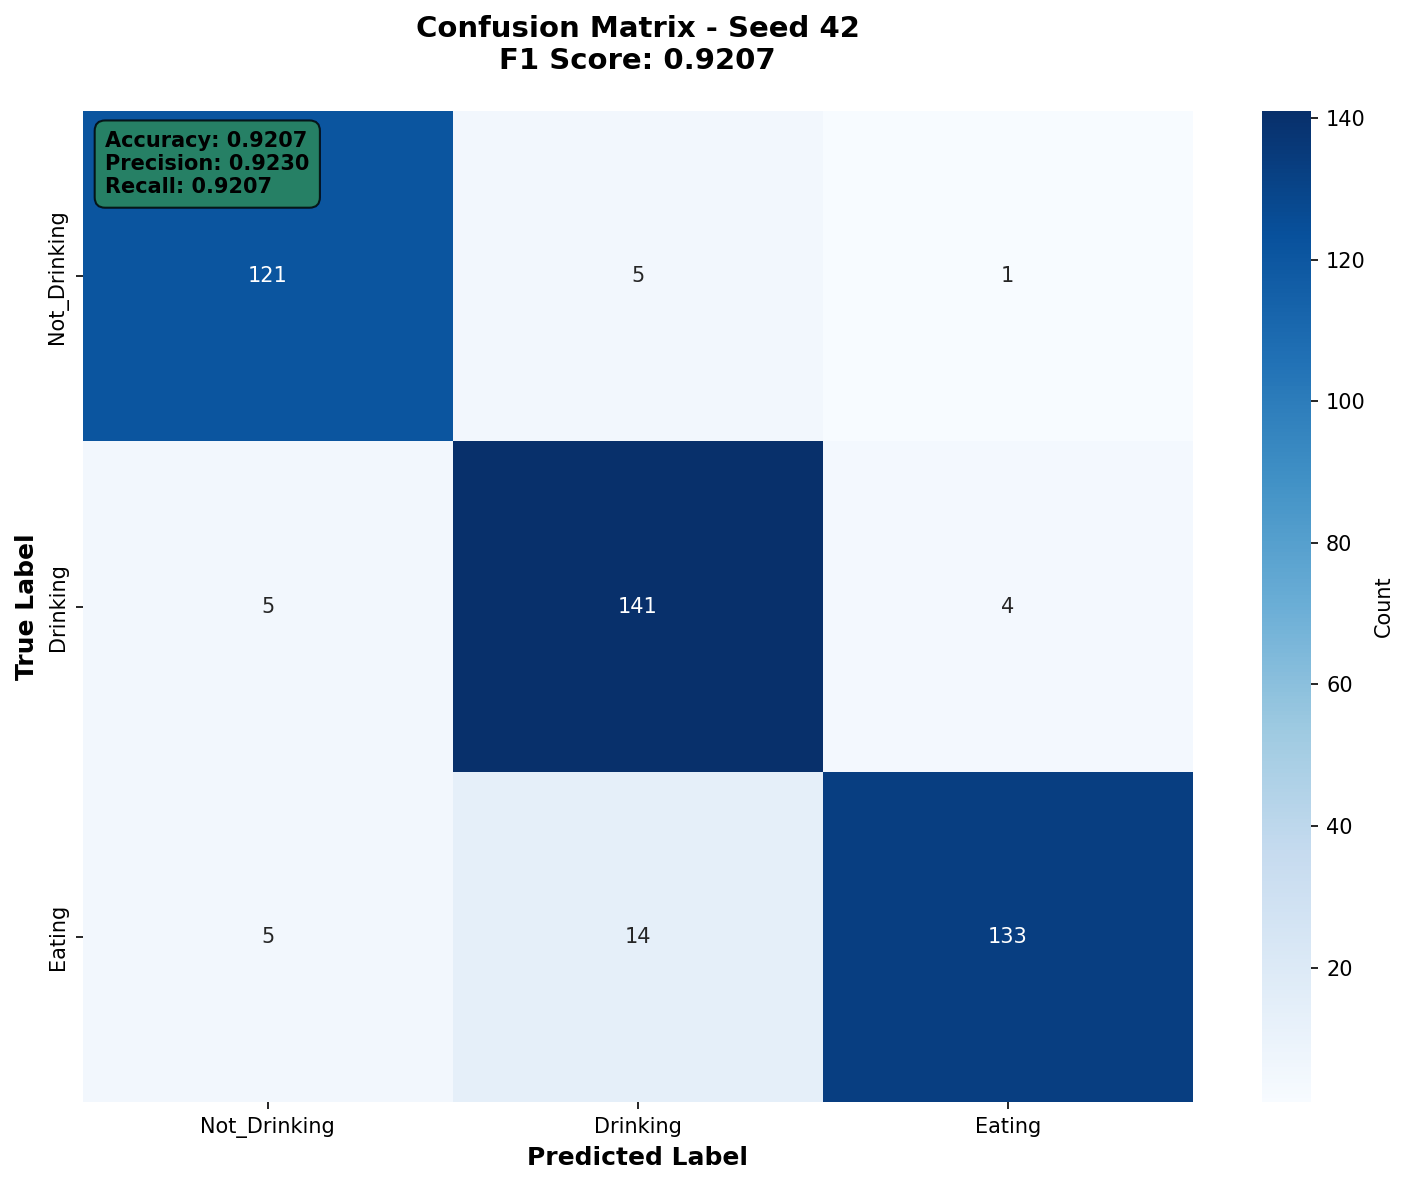

✅ Confusion matrix saved for seed 42
   📷 PNG: confusion_matrix_plots/confusion_matrix_seed_42.png
   📄 PDF: confusion_matrix_plots/confusion_matrix_seed_42.pdf
   📊 Plotting seed 192021 (10/16)


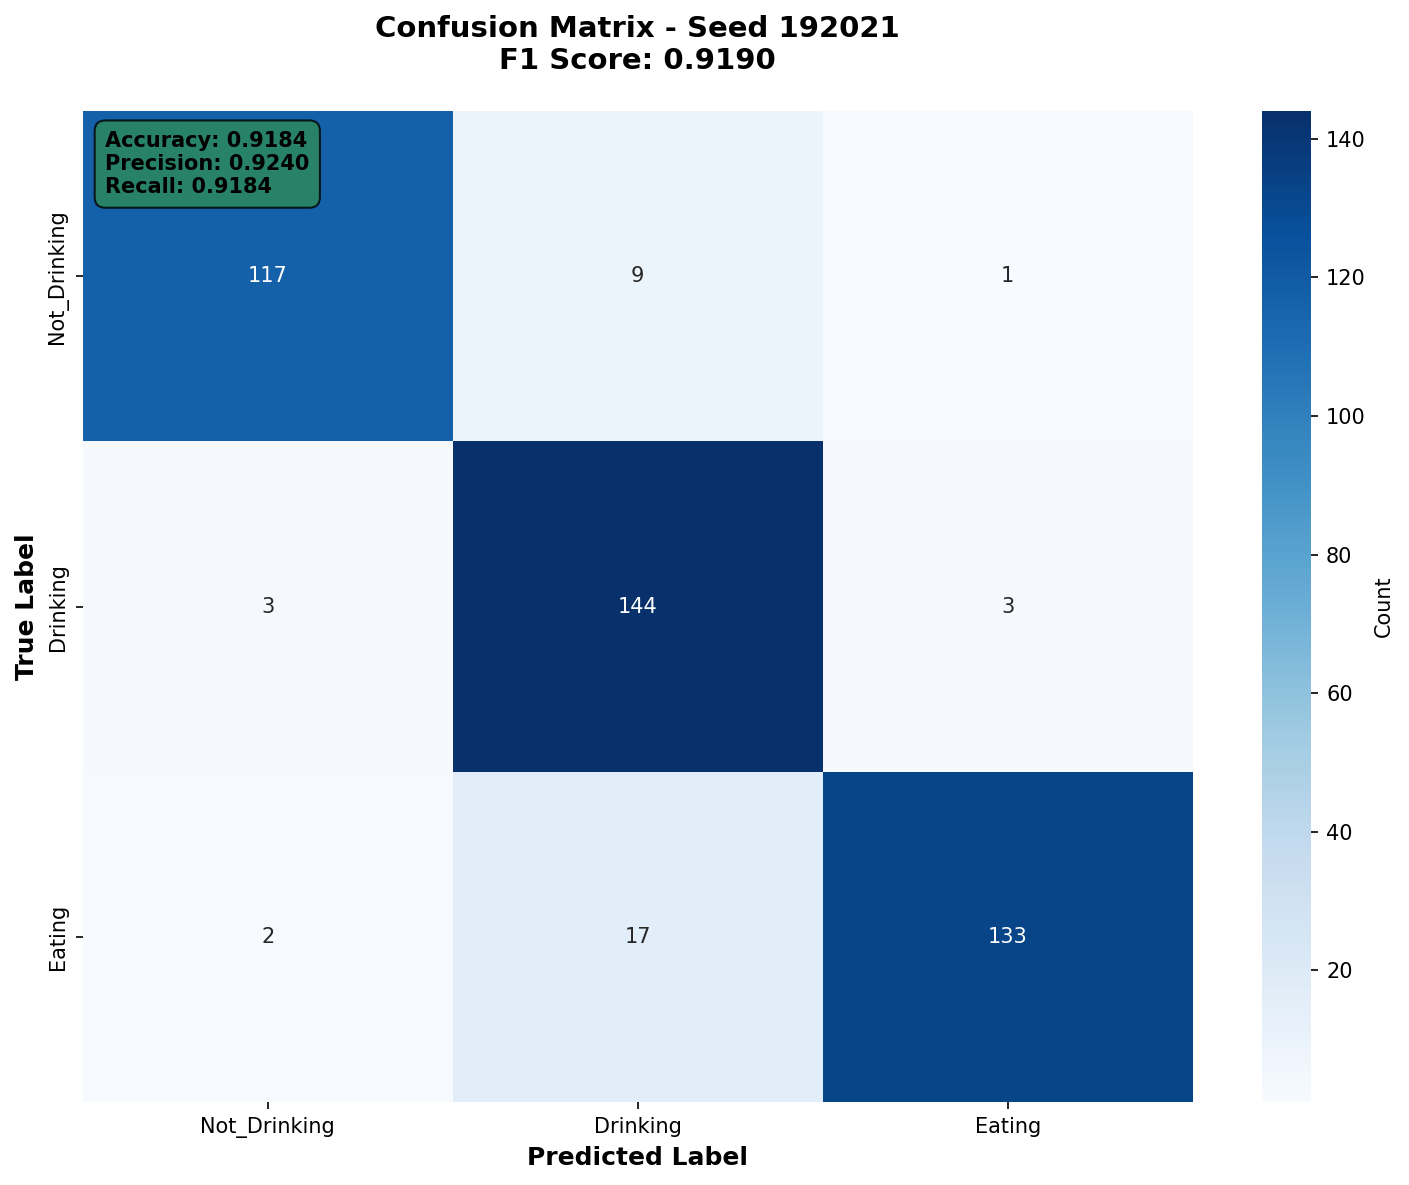

✅ Confusion matrix saved for seed 192021
   📷 PNG: confusion_matrix_plots/confusion_matrix_seed_192021.png
   📄 PDF: confusion_matrix_plots/confusion_matrix_seed_192021.pdf
   📊 Plotting seed 789 (11/16)


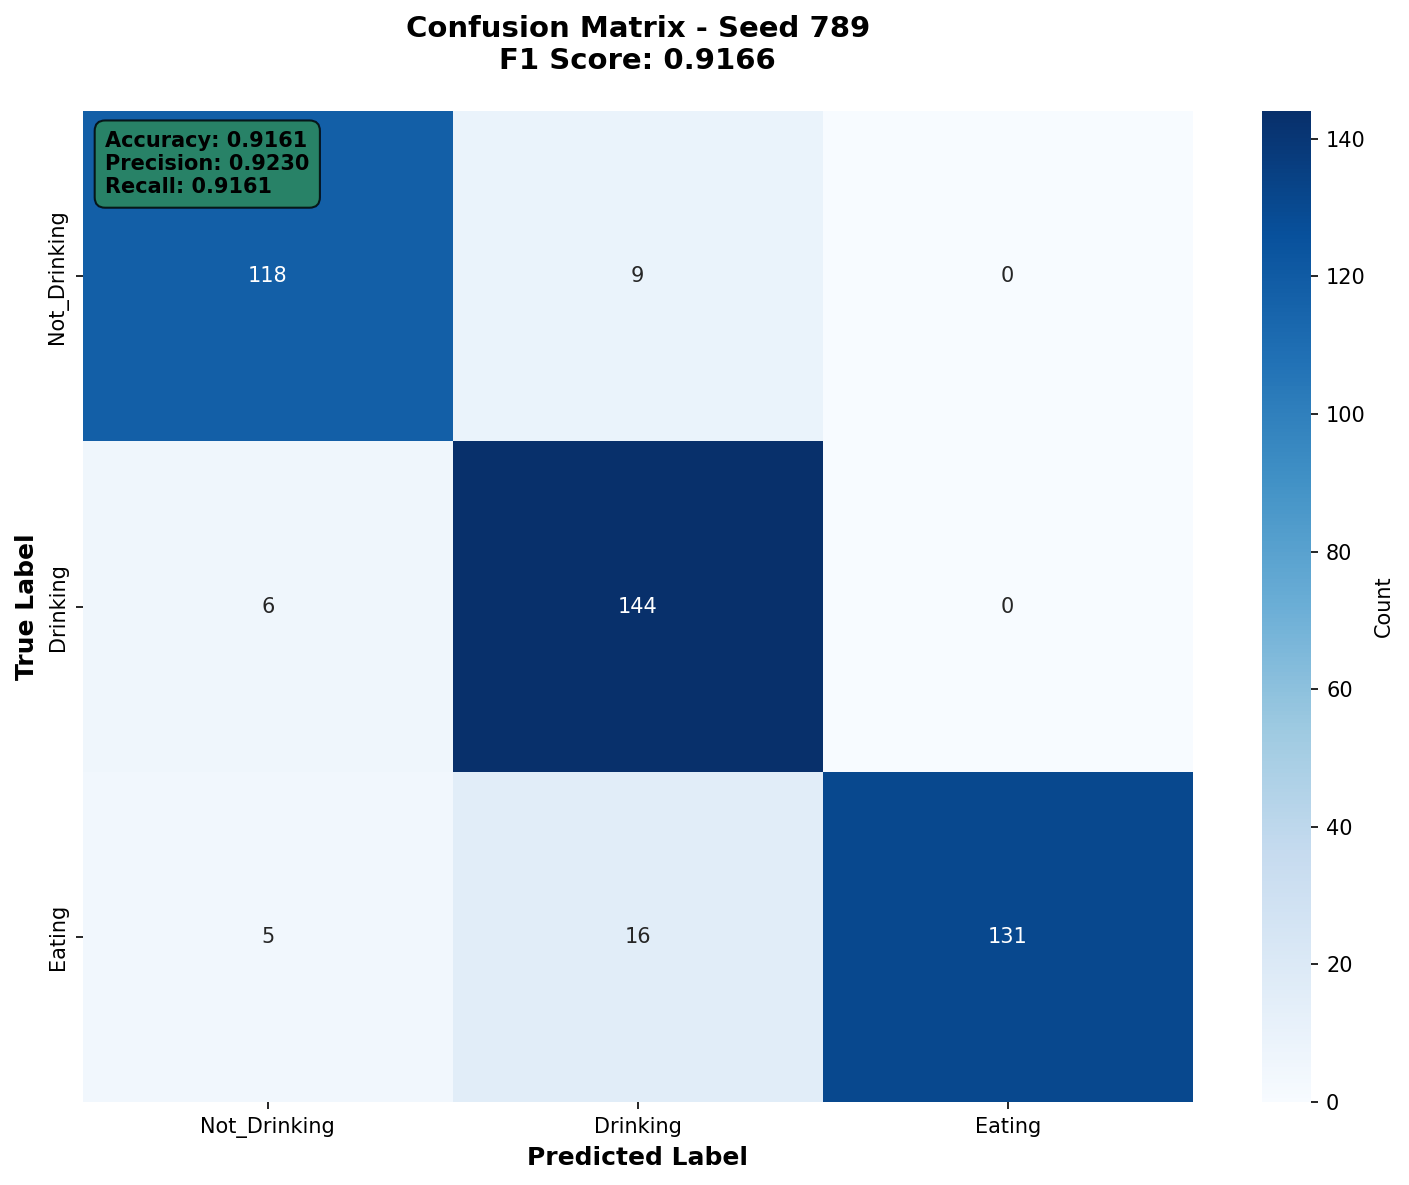

✅ Confusion matrix saved for seed 789
   📷 PNG: confusion_matrix_plots/confusion_matrix_seed_789.png
   📄 PDF: confusion_matrix_plots/confusion_matrix_seed_789.pdf
   📊 Plotting seed 131415 (12/16)


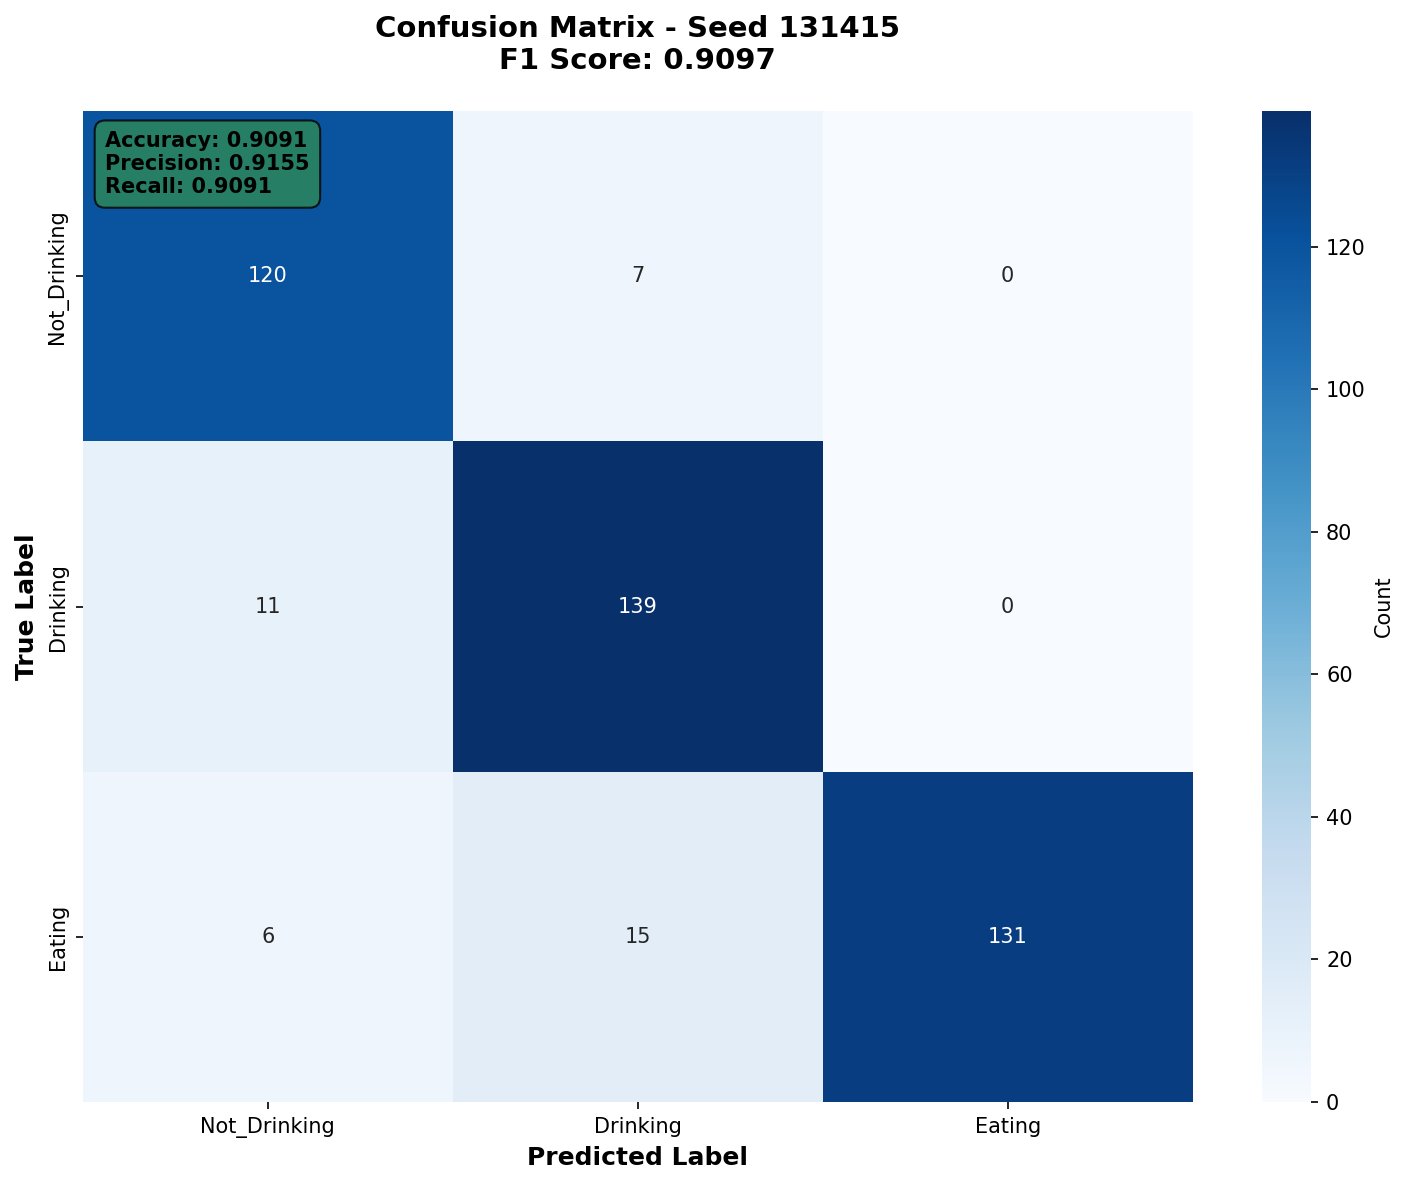

✅ Confusion matrix saved for seed 131415
   📷 PNG: confusion_matrix_plots/confusion_matrix_seed_131415.png
   📄 PDF: confusion_matrix_plots/confusion_matrix_seed_131415.pdf
   📊 Plotting seed 202 (13/16)


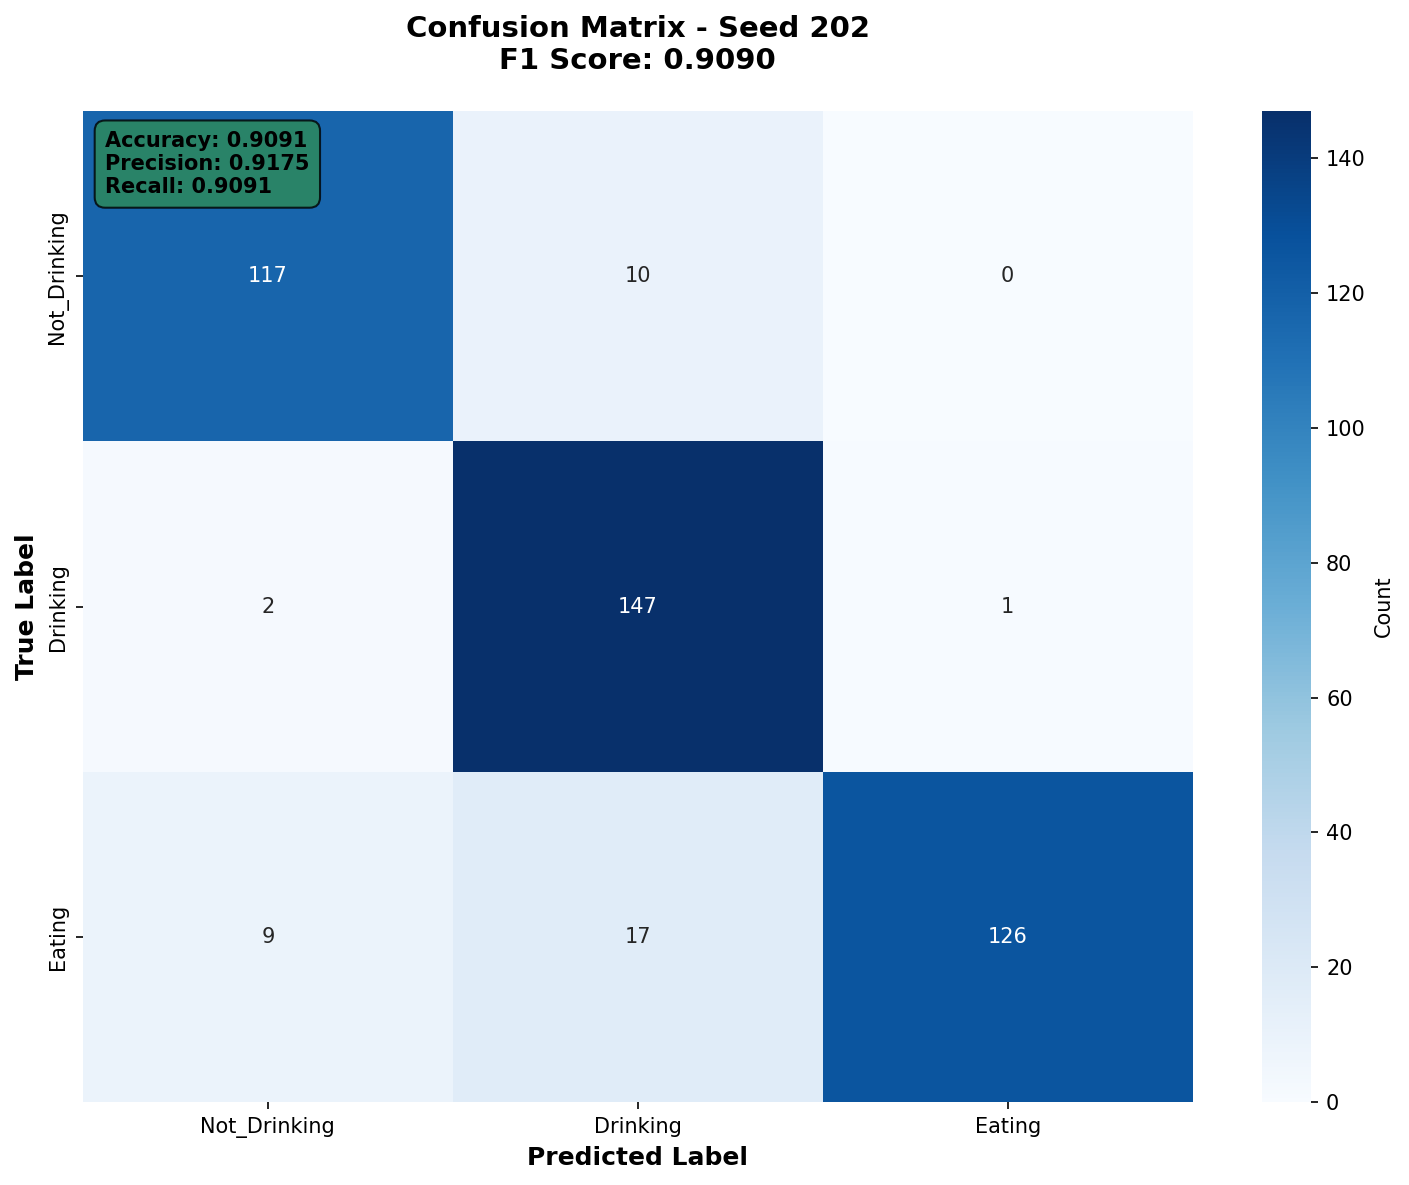

✅ Confusion matrix saved for seed 202
   📷 PNG: confusion_matrix_plots/confusion_matrix_seed_202.png
   📄 PDF: confusion_matrix_plots/confusion_matrix_seed_202.pdf
   📊 Plotting seed 505 (14/16)


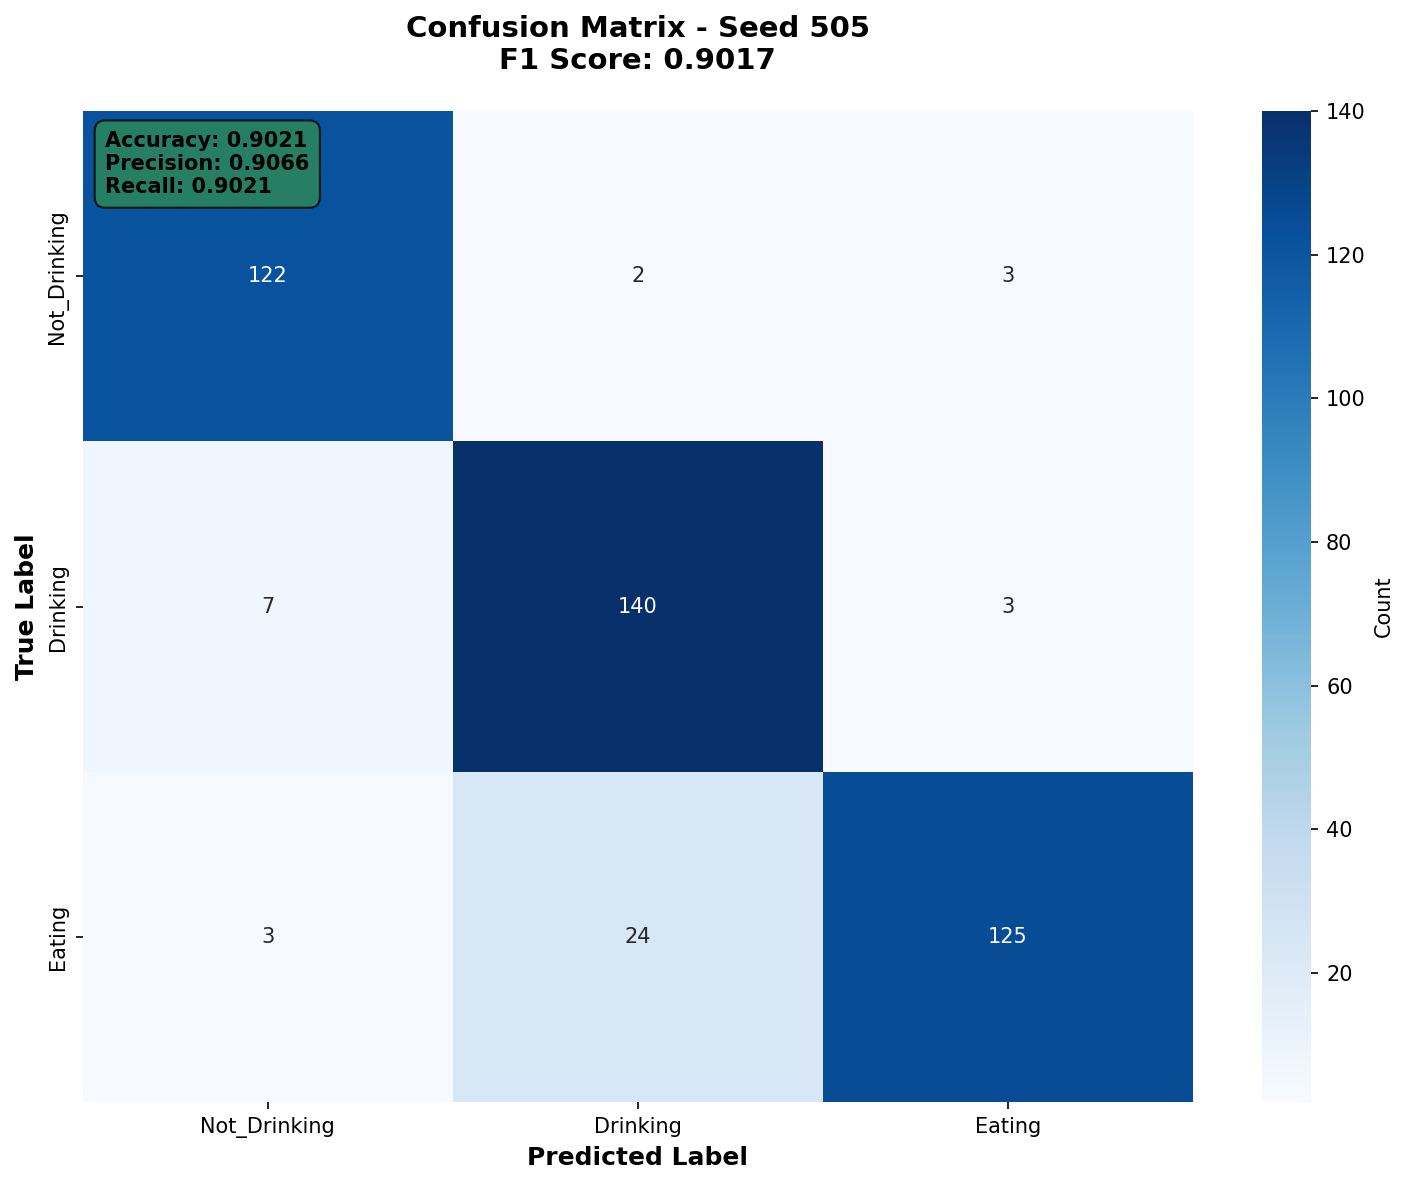

✅ Confusion matrix saved for seed 505
   📷 PNG: confusion_matrix_plots/confusion_matrix_seed_505.png
   📄 PDF: confusion_matrix_plots/confusion_matrix_seed_505.pdf
   📊 Plotting seed 456 (15/16)


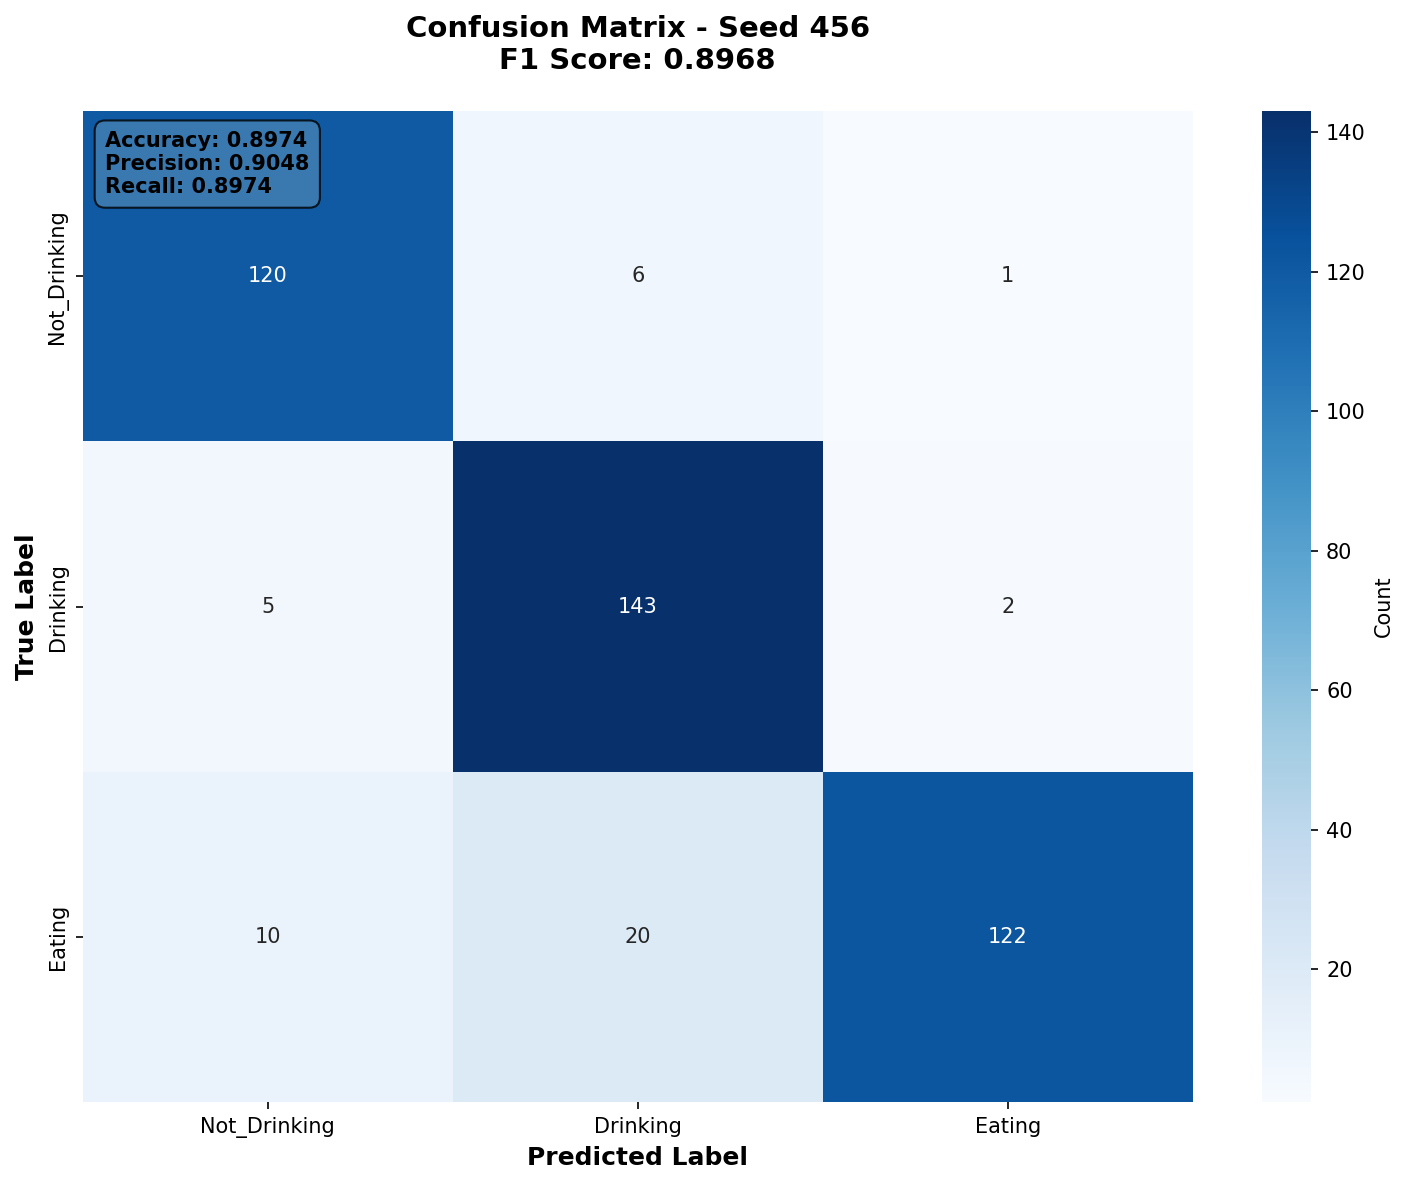

✅ Confusion matrix saved for seed 456
   📷 PNG: confusion_matrix_plots/confusion_matrix_seed_456.png
   📄 PDF: confusion_matrix_plots/confusion_matrix_seed_456.pdf
   📊 Plotting seed 222324 (16/16)


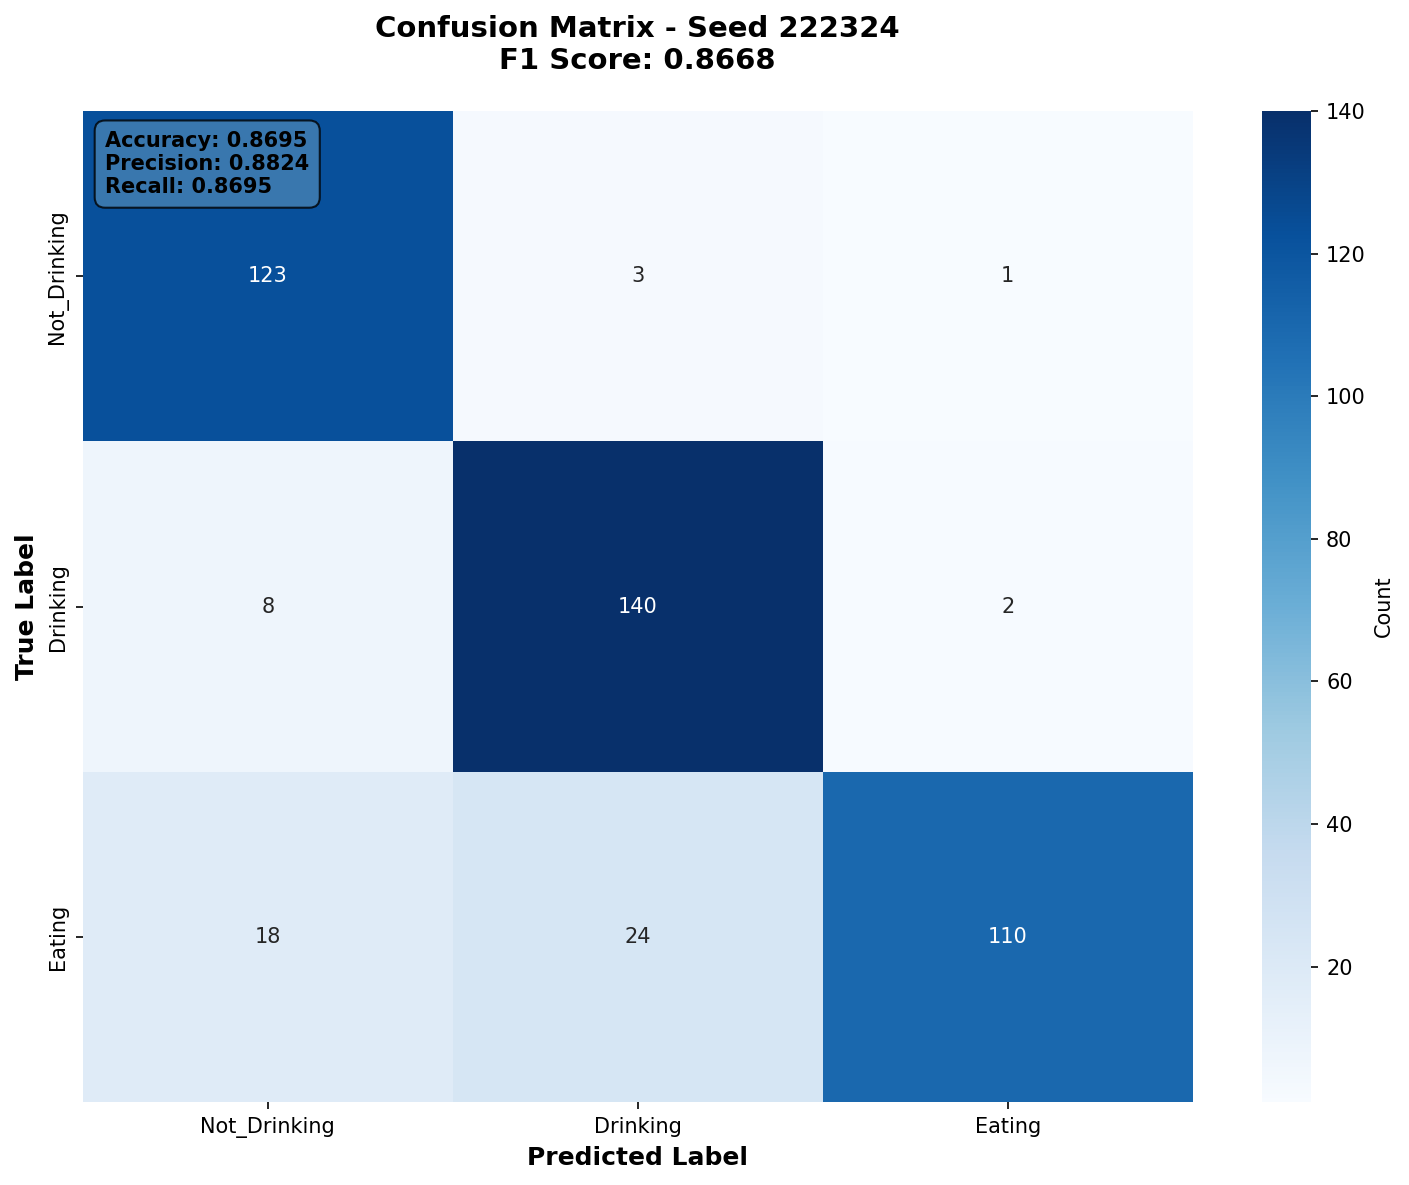

✅ Confusion matrix saved for seed 222324
   📷 PNG: confusion_matrix_plots/confusion_matrix_seed_222324.png
   📄 PDF: confusion_matrix_plots/confusion_matrix_seed_222324.pdf

2. Creating confusion matrices comparison...


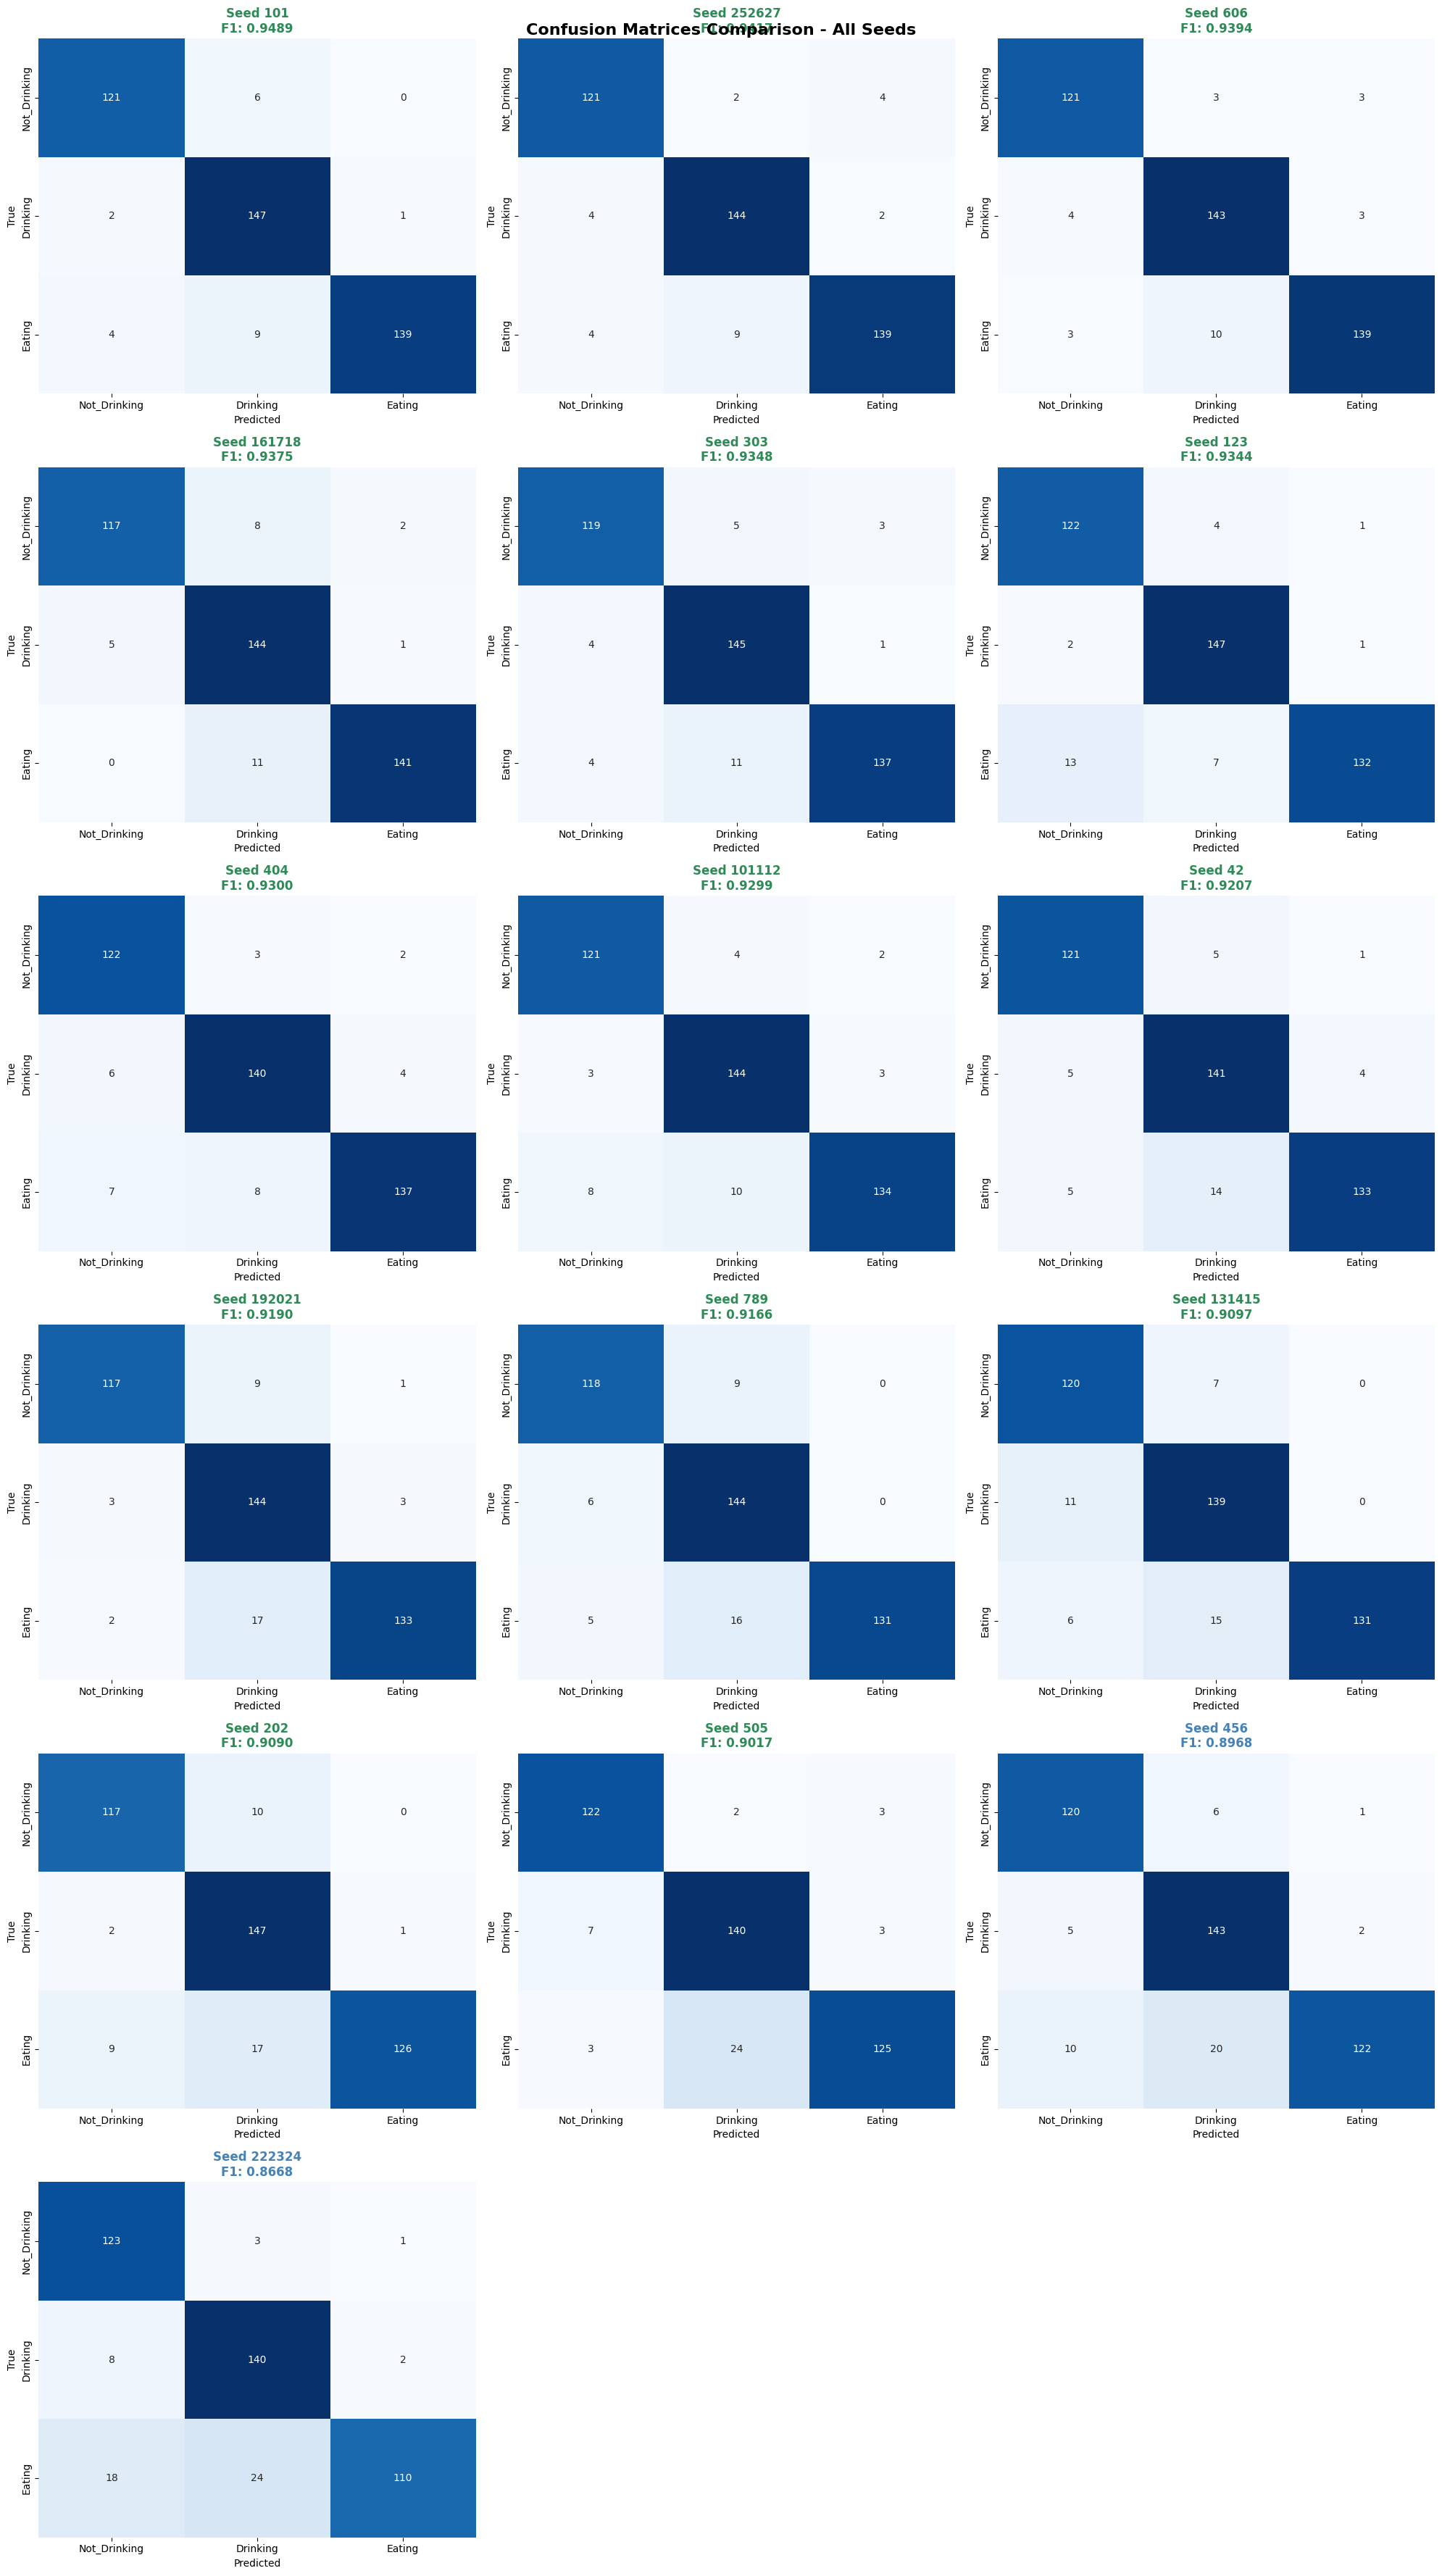

✅ All confusion matrices comparison saved
   📷 PNG: confusion_matrix_plots/all_confusion_matrices_comparison.png
   📄 PDF: confusion_matrix_plots/all_confusion_matrices_comparison.pdf

3. Creating performance summary...


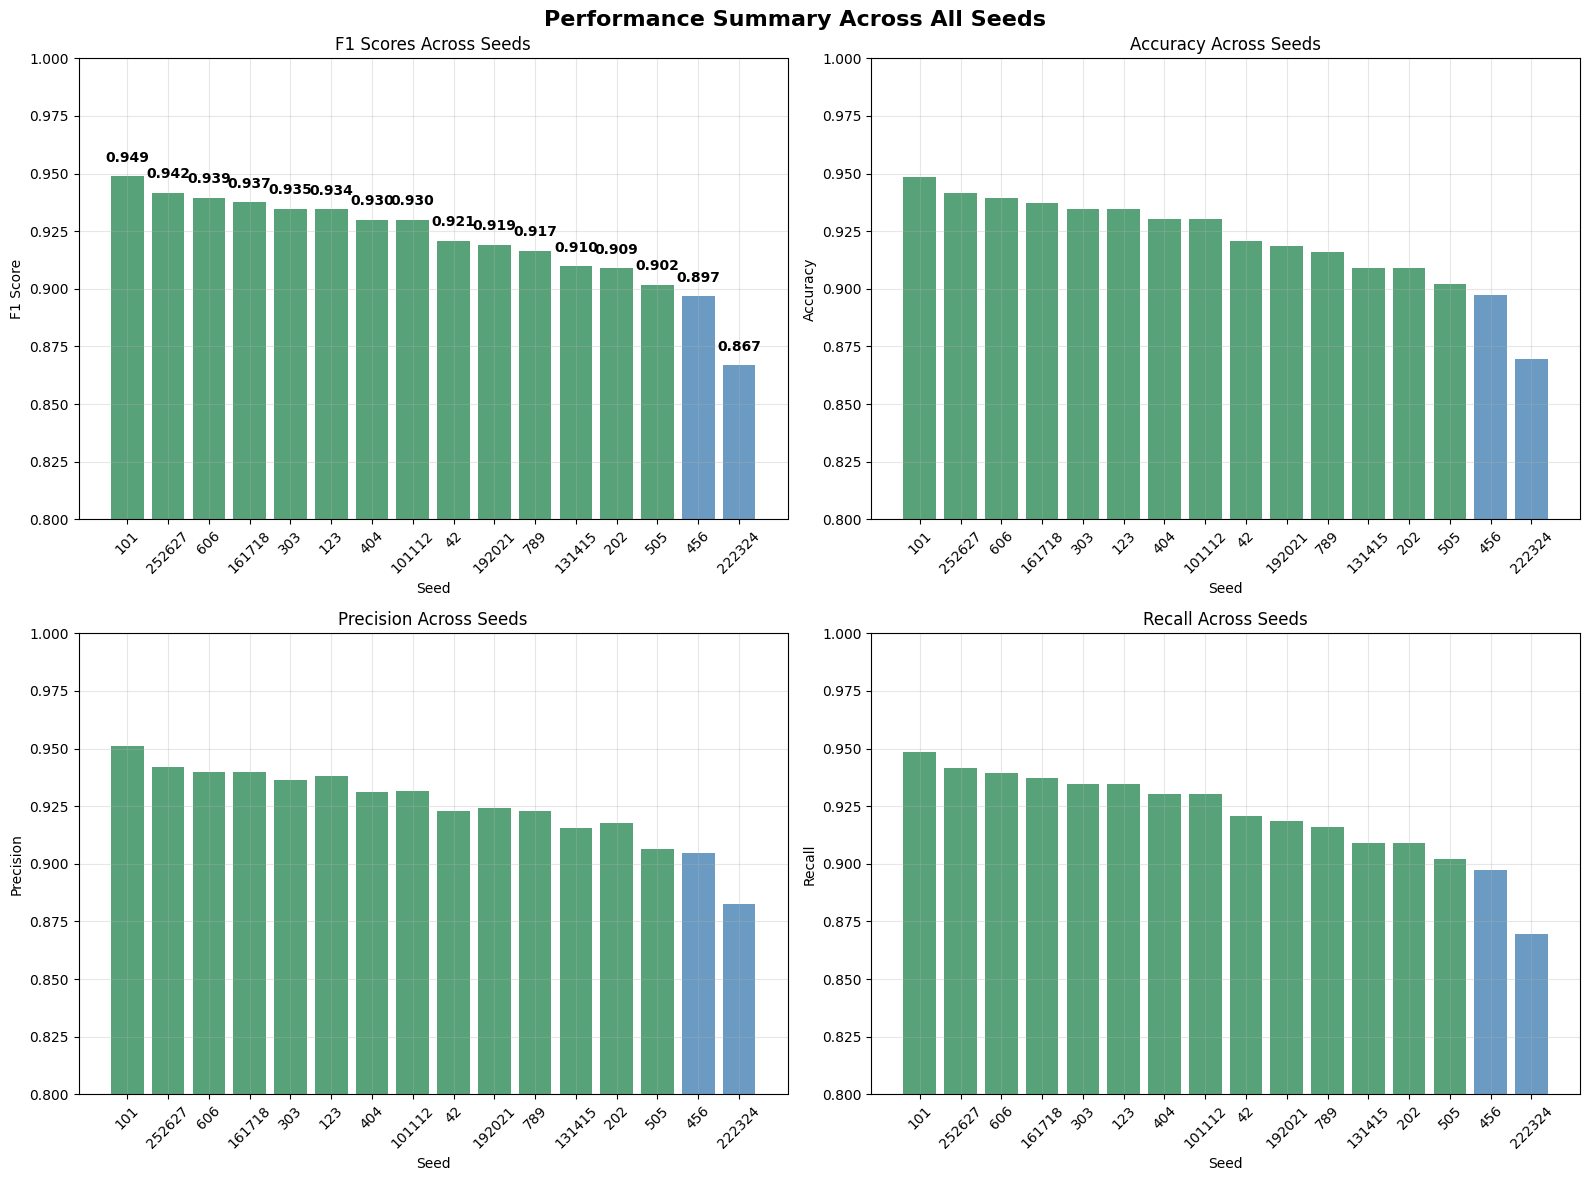

✅ Performance summary plot saved
   📷 PNG: confusion_matrix_plots/performance_summary.png
   📄 PDF: confusion_matrix_plots/performance_summary.pdf

4. Creating per-class performance breakdown...


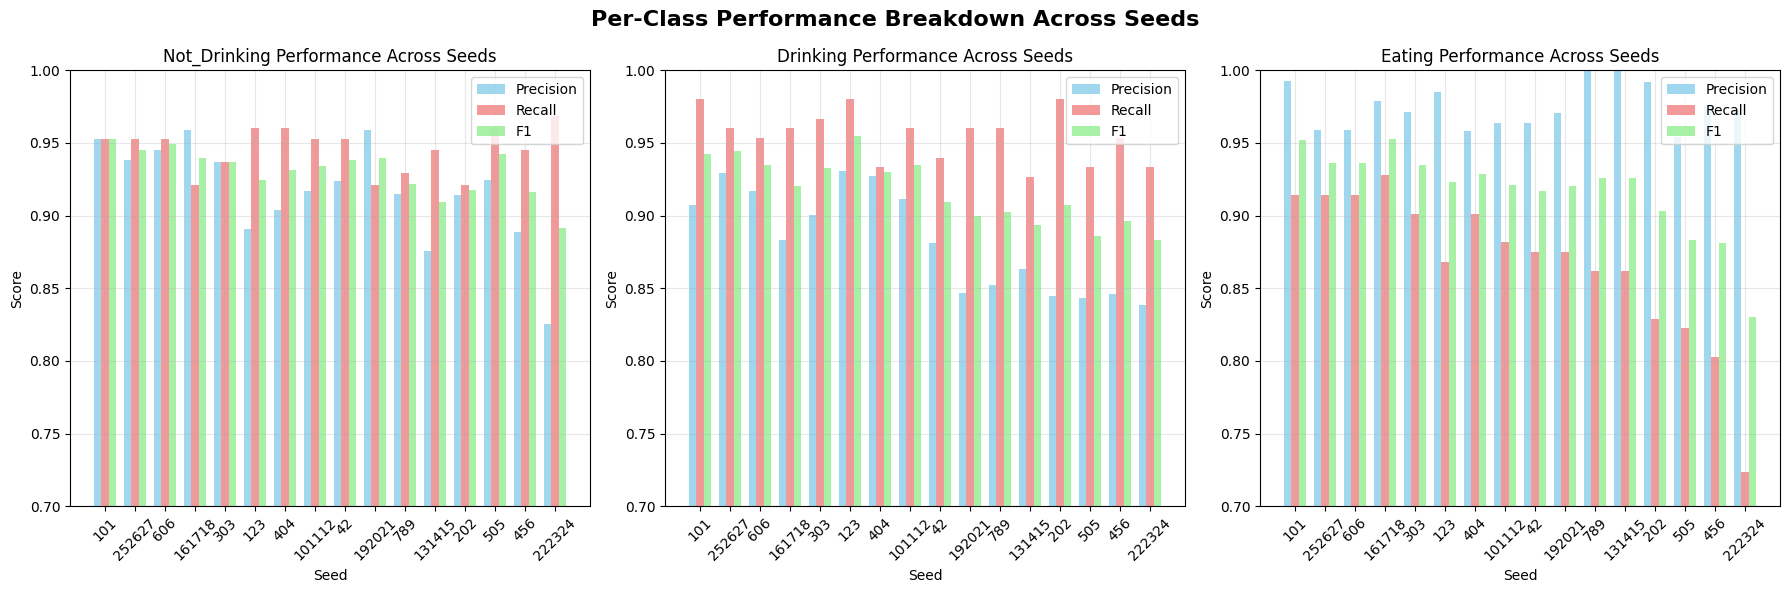

✅ Per-class performance breakdown saved
   📷 PNG: confusion_matrix_plots/per_class_performance_breakdown.png
   📄 PDF: confusion_matrix_plots/per_class_performance_breakdown.pdf

5. Creating performance comparison table...
✅ Performance comparison table saved

🔍 Verifying PNG files creation...
✅ Found 19 PNG files:
   📷 confusion_matrix_seed_161718.png (15,130 bytes)
      ✅ Image readable: 1980x1499 pixels
   📷 all_confusion_matrices_comparison.png (15,130 bytes)
      ✅ Image readable: 1980x1499 pixels
   📷 confusion_matrix_seed_252627.png (15,130 bytes)
      ✅ Image readable: 1980x1499 pixels
   📷 per_class_performance_breakdown.png (15,130 bytes)
      ✅ Image readable: 1980x1499 pixels
   📷 confusion_matrix_seed_123.png (15,130 bytes)
      ✅ Image readable: 1980x1499 pixels
   📷 confusion_matrix_seed_131415.png (15,130 bytes)
      ✅ Image readable: 1980x1499 pixels
   📷 confusion_matrix_seed_192021.png (15,130 bytes)
      ✅ Image readable: 1980x1499 pixels
   📷 confusion_matri

In [12]:
# ====================================================================
# PLOT CONFUSION MATRICES FOR ALL SEEDS FROM classification_with_random_seeds.py
# ====================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score, accuracy_score

# Set matplotlib to show plots on screen
plt.ion()  # Turn on interactive mode

# ====================================================================
# CONFIGURATION
# ====================================================================

# Results directory from classification_with_random_seeds.py
RESULTS_DIR = "results_seed_*"  # This will match all seed directories

# Class names
CLASS_NAMES = ["Not_Drinking", "Drinking", "Eating"]

# Colors for different performance levels
COLORS = {
    'excellent': '#2E8B57',  # Sea Green
    'good': '#4682B4',       # Steel Blue
    'average': '#DAA520',    # Goldenrod
    'poor': '#DC143C'        # Crimson
}

# ====================================================================
# UTILITY FUNCTIONS
# ====================================================================

def get_performance_color(f1_score):
    """Get color based on F1 score performance"""
    if f1_score >= 0.90:
        return COLORS['excellent']
    elif f1_score >= 0.80:
        return COLORS['good']
    elif f1_score >= 0.70:
        return COLORS['average']
    else:
        return COLORS['poor']

def load_results_from_seed_directory(seed_dir):
    """Load results from a specific seed directory"""
    try:
        # Load predictions
        predictions_file = seed_dir / "classification_results_seed_*.xlsx"
        predictions_files = list(seed_dir.glob("classification_results_seed_*.xlsx"))
        
        if not predictions_files:
            print(f"❌ No predictions file found in {seed_dir}")
            return None
        
        predictions_file = predictions_files[0]
        df = pd.read_excel(predictions_file)
        
        # Extract seed number from directory name
        seed = seed_dir.name.split('_')[-1]
        
        # Load true and predicted labels
        y_test = df["True_Label"].values
        y_pred = df["Predicted_Label"].values
        
        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        
        # Per-class metrics
        class_precision = precision_score(y_test, y_pred, average=None, zero_division=0)
        class_recall = recall_score(y_test, y_pred, average=None, zero_division=0)
        class_f1 = f1_score(y_test, y_pred, average=None, zero_division=0)
        
        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        
        return {
            'seed': seed,
            'y_test': y_test,
            'y_pred': y_pred,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'class_precision': class_precision,
            'class_recall': class_recall,
            'class_f1': class_f1,
            'confusion_matrix': cm,
            'class_names': CLASS_NAMES,
            'predictions_df': df
        }
        
    except Exception as e:
        print(f"❌ Error loading results from {seed_dir}: {str(e)}")
        return None

def find_all_seed_directories():
    """Find all seed result directories"""
    current_dir = Path(".")
    seed_dirs = [d for d in current_dir.iterdir() if d.is_dir() and d.name.startswith('results_seed_')]
    return sorted(seed_dirs, key=lambda x: int(x.name.split('_')[-1]))

# ====================================================================
# PLOTTING FUNCTIONS
# ====================================================================

def plot_individual_confusion_matrix(results, save_dir, show_plot=True):
    """Plot individual confusion matrix for a seed"""
    seed = results['seed']
    cm = results['confusion_matrix']
    f1 = results['f1']
    
    # Create figure
    plt.figure(figsize=(10, 8), dpi=150)
    
    # Create heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                cbar_kws={'label': 'Count'})
    
    # Customize plot
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.ylabel('True Label', fontsize=12, fontweight='bold')
    plt.title(f'Confusion Matrix - Seed {seed}\nF1 Score: {f1:.4f}', 
              fontsize=14, fontweight='bold', pad=20)
    
    # Add performance indicators
    performance_color = get_performance_color(f1)
    plt.text(0.02, 0.98, f'Accuracy: {results["accuracy"]:.4f}\nPrecision: {results["precision"]:.4f}\nRecall: {results["recall"]:.4f}',
             transform=plt.gca().transAxes, fontsize=10, fontweight='bold',
             verticalalignment='top', bbox=dict(boxstyle="round,pad=0.5", 
             facecolor=performance_color, alpha=0.8, edgecolor='black'))
    
    plt.tight_layout()
    
    # Show plot on screen if requested
    if show_plot:
        plt.show()
        plt.pause(2)  # Pause to show the plot
    
    # Save plot
    png_file = save_dir / f"confusion_matrix_seed_{seed}.png"
    pdf_file = save_dir / f"confusion_matrix_seed_{seed}.pdf"
    
    plt.savefig(png_file, format='png', dpi=300, bbox_inches='tight')
    plt.savefig(pdf_file, format='pdf', bbox_inches='tight', dpi=300)
    
    print(f"✅ Confusion matrix saved for seed {seed}")
    print(f"   📷 PNG: {png_file}")
    print(f"   📄 PDF: {pdf_file}")
    
    plt.close()

def plot_all_confusion_matrices_comparison(all_results, save_dir, show_plot=True):
    """Plot all confusion matrices in a grid for comparison"""
    n_seeds = len(all_results)
    n_cols = 3
    n_rows = (n_seeds + n_cols - 1) // n_cols
    
    # Create large figure
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 6 * n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    elif n_cols == 1:
        axes = axes.reshape(-1, 1)
    
    # Flatten axes for easier indexing
    axes_flat = axes.flatten()
    
    for idx, results in enumerate(all_results):
        if idx >= len(axes_flat):
            break
            
        ax = axes_flat[idx]
        seed = results['seed']
        cm = results['confusion_matrix']
        f1 = results['f1']
        
        # Create heatmap
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                    ax=ax, cbar=False)
        
        # Customize subplot
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')
        ax.set_title(f'Seed {seed}\nF1: {f1:.4f}')
        
        # Color the title based on performance
        performance_color = get_performance_color(f1)
        ax.title.set_color(performance_color)
        ax.title.set_fontweight('bold')
    
    # Hide empty subplots
    for idx in range(len(all_results), len(axes_flat)):
        axes_flat[idx].set_visible(False)
    
    plt.suptitle('Confusion Matrices Comparison - All Seeds', fontsize=16, fontweight='bold')
    plt.tight_layout()
    
    # Show plot on screen if requested
    if show_plot:
        plt.show()
        plt.pause(3)  # Pause to show the plot
    
    # Save comparison plot
    png_file = save_dir / "all_confusion_matrices_comparison.png"
    pdf_file = save_dir / "all_confusion_matrices_comparison.pdf"
    
    plt.savefig(png_file, format='png', dpi=300, bbox_inches='tight')
    plt.savefig(pdf_file, format='pdf', bbox_inches='tight', dpi=300)
    
    print(f"✅ All confusion matrices comparison saved")
    print(f"   📷 PNG: {png_file}")
    print(f"   📄 PDF: {pdf_file}")
    
    plt.close()

def plot_performance_summary(all_results, save_dir, show_plot=True):
    """Plot performance summary across all seeds"""
    # Sort by F1 score
    all_results.sort(key=lambda x: x['f1'], reverse=True)
    
    seeds = [r['seed'] for r in all_results]
    f1_scores = [r['f1'] for r in all_results]
    accuracy_scores = [r['accuracy'] for r in all_results]
    precision_scores = [r['precision'] for r in all_results]
    recall_scores = [r['recall'] for r in all_results]
    
    # Create performance summary plot
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    
    # F1 Scores
    bars1 = ax1.bar(range(len(seeds)), f1_scores, color=[get_performance_color(f1) for f1 in f1_scores], alpha=0.8)
    ax1.set_xlabel('Seed')
    ax1.set_ylabel('F1 Score')
    ax1.set_title('F1 Scores Across Seeds')
    ax1.set_xticks(range(len(seeds)))
    ax1.set_xticklabels(seeds, rotation=45)
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(0.8, 1.0)
    
    # Add value labels on bars
    for i, (bar, score) in enumerate(zip(bars1, f1_scores)):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
                f'{score:.3f}', ha='center', va='bottom', fontweight='bold')
    
    # Accuracy Scores
    bars2 = ax2.bar(range(len(seeds)), accuracy_scores, color=[get_performance_color(f1) for f1 in f1_scores], alpha=0.8)
    ax2.set_xlabel('Seed')
    ax2.set_ylabel('Accuracy')
    ax2.set_title('Accuracy Across Seeds')
    ax2.set_xticks(range(len(seeds)))
    ax2.set_xticklabels(seeds, rotation=45)
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(0.8, 1.0)
    
    # Precision Scores
    bars3 = ax3.bar(range(len(seeds)), precision_scores, color=[get_performance_color(f1) for f1 in f1_scores], alpha=0.8)
    ax3.set_xlabel('Seed')
    ax3.set_ylabel('Precision')
    ax3.set_title('Precision Across Seeds')
    ax3.set_xticks(range(len(seeds)))
    ax3.set_xticklabels(seeds, rotation=45)
    ax3.grid(True, alpha=0.3)
    ax3.set_ylim(0.8, 1.0)
    
    # Recall Scores
    bars4 = ax4.bar(range(len(seeds)), recall_scores, color=[get_performance_color(f1) for f1 in f1_scores], alpha=0.8)
    ax4.set_xlabel('Seed')
    ax4.set_ylabel('Recall')
    ax4.set_title('Recall Across Seeds')
    ax4.set_xticks(range(len(seeds)))
    ax4.set_xticklabels(seeds, rotation=45)
    ax4.grid(True, alpha=0.3)
    ax4.set_ylim(0.8, 1.0)
    
    plt.suptitle('Performance Summary Across All Seeds', fontsize=16, fontweight='bold')
    plt.tight_layout()
    
    # Show plot on screen if requested
    if show_plot:
        plt.show()
        plt.pause(3)  # Pause to show the plot
    
    # Save performance summary
    png_file = save_dir / "performance_summary.png"
    pdf_file = save_dir / "performance_summary.pdf"
    
    plt.savefig(png_file, format='png', dpi=300, bbox_inches='tight')
    plt.savefig(pdf_file, format='pdf', bbox_inches='tight', dpi=300)
    
    print(f"✅ Performance summary plot saved")
    print(f"   📷 PNG: {png_file}")
    print(f"   📄 PDF: {pdf_file}")
    
    plt.close()

def plot_class_performance_breakdown(all_results, save_dir, show_plot=True):
    """Plot per-class performance breakdown"""
    # Prepare data for per-class analysis
    class_data = {class_name: {'precision': [], 'recall': [], 'f1': []} for class_name in CLASS_NAMES}
    
    for results in all_results:
        for i, class_name in enumerate(CLASS_NAMES):
            class_data[class_name]['precision'].append(results['class_precision'][i])
            class_data[class_name]['recall'].append(results['class_recall'][i])
            class_data[class_name]['f1'].append(results['class_f1'][i])
    
    # Create per-class performance plot
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    for i, class_name in enumerate(CLASS_NAMES):
        ax = axes[i]
        
        # Get data for this class
        precision_vals = class_data[class_name]['precision']
        recall_vals = class_data[class_name]['recall']
        f1_vals = class_data[class_name]['f1']
        
        # Create bar plot
        x_pos = np.arange(len(all_results))
        width = 0.25
        
        bars1 = ax.bar(x_pos - width, precision_vals, width, label='Precision', alpha=0.8, color='skyblue')
        bars2 = ax.bar(x_pos, recall_vals, width, label='Recall', alpha=0.8, color='lightcoral')
        bars3 = ax.bar(x_pos + width, f1_vals, width, label='F1', alpha=0.8, color='lightgreen')
        
        ax.set_xlabel('Seed')
        ax.set_ylabel('Score')
        ax.set_title(f'{class_name} Performance Across Seeds')
        ax.set_xticks(x_pos)
        ax.set_xticklabels([r['seed'] for r in all_results], rotation=45)
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0.7, 1.0)
    
    plt.suptitle('Per-Class Performance Breakdown Across Seeds', fontsize=16, fontweight='bold')
    plt.tight_layout()
    
    # Show plot on screen if requested
    if show_plot:
        plt.show()
        plt.pause(3)  # Pause to show the plot
    
    # Save per-class breakdown
    png_file = save_dir / "per_class_performance_breakdown.png"
    pdf_file = save_dir / "per_class_performance_breakdown.pdf"
    
    plt.savefig(png_file, format='png', dpi=300, bbox_inches='tight')
    plt.savefig(pdf_file, format='pdf', bbox_inches='tight', dpi=300)
    
    print(f"✅ Per-class performance breakdown saved")
    print(f"   📷 PNG: {png_file}")
    print(f"   📄 PDF: {pdf_file}")
    
    plt.close()

def create_performance_table(all_results, save_dir):
    """Create and save performance comparison table"""
    # Sort by F1 score
    all_results.sort(key=lambda x: x['f1'], reverse=True)
    
    # Create comparison table
    table_data = []
    for i, results in enumerate(all_results, 1):
        table_data.append({
            'Rank': i,
            'Seed': results['seed'],
            'F1 Score': f"{results['f1']:.4f}",
            'Accuracy': f"{results['accuracy']:.4f}",
            'Precision': f"{results['precision']:.4f}",
            'Recall': f"{results['recall']:.4f}",
            'Not_Drinking_Precision': f"{results['class_precision'][0]:.4f}",
            'Not_Drinking_Recall': f"{results['class_recall'][0]:.4f}",
            'Not_Drinking_F1': f"{results['class_f1'][0]:.4f}",
            'Drinking_Precision': f"{results['class_precision'][1]:.4f}",
            'Drinking_Recall': f"{results['class_recall'][1]:.4f}",
            'Drinking_F1': f"{results['class_f1'][1]:.4f}",
            'Eating_Precision': f"{results['class_precision'][2]:.4f}",
            'Eating_Recall': f"{results['class_recall'][2]:.4f}",
            'Eating_F1': f"{results['class_f1'][2]:.4f}"
        })
    
    # Create DataFrame and save
    comparison_df = pd.DataFrame(table_data)
    comparison_df.to_excel(save_dir / "detailed_performance_comparison.xlsx", index=False)
    
    # Also save as CSV for easy viewing
    comparison_df.to_csv(save_dir / "detailed_performance_comparison.csv", index=False)
    
    print(f"✅ Performance comparison table saved")
    
    return comparison_df

def verify_png_files_created(save_dir):
    """Verify that PNG files were actually created and are visible"""
    print(f"\n🔍 Verifying PNG files creation...")
    
    png_files = list(save_dir.glob("*.png"))
    if png_files:
        print(f"✅ Found {len(png_files)} PNG files:")
        for png_file in png_files:
            file_size = png_file.stat().st_size
            print(f"   📷 {png_file.name} ({file_size:,} bytes)")
            
            # Check if file is readable
            try:
                from PIL import Image
                img = Image.open(png_file)
                print(f"      ✅ Image readable: {img.size[0]}x{img.size[1]} pixels")
            except Exception as e:
                print(f"      ❌ Image not readable: {e}")
    else:
        print("❌ No PNG files found!")
    
    return png_files

# ====================================================================
# MAIN EXECUTION
# ====================================================================

def main():
    """Main function to generate all plots and analysis"""
    print("🔍 Starting confusion matrix analysis for all seeds...")
    
    # Find all seed directories
    seed_dirs = find_all_seed_directories()
    
    if not seed_dirs:
        print("❌ No seed result directories found!")
        print("Make sure you've run classification_with_random_seeds.py first")
        return
    
    print(f"✅ Found {len(seed_dirs)} seed directories:")
    for seed_dir in seed_dirs:
        print(f"   - {seed_dir.name}")
    
    # Create plots directory
    plots_dir = Path("confusion_matrix_plots")
    plots_dir.mkdir(exist_ok=True)
    
    print(f"📁 Plots will be saved to: {plots_dir.absolute()}")
    
    # Load results from all seeds
    all_results = []
    for seed_dir in seed_dirs:
        results = load_results_from_seed_directory(seed_dir)
        if results is not None:
            all_results.append(results)
            print(f"✅ Loaded results for seed {results['seed']}: F1 = {results['f1']:.4f}")
    
    if not all_results:
        print("❌ No results loaded!")
        return
    
    print(f"\n📊 Successfully loaded {len(all_results)} seed results")
    
    # Sort by F1 score for ranking
    all_results.sort(key=lambda x: x['f1'], reverse=True)
    
    # Generate all plots and analysis
    print(f"\n🎨 Generating plots and analysis...")
    print("📺 Plots will be displayed on screen (close each plot to continue)")
    
    # 1. Individual confusion matrices
    print("\n1. Creating individual confusion matrices...")
    for i, results in enumerate(all_results):
        print(f"   📊 Plotting seed {results['seed']} ({i+1}/{len(all_results)})")
        plot_individual_confusion_matrix(results, plots_dir, show_plot=True)
        input(f"   Press Enter to continue to next plot...")
    
    # 2. All confusion matrices comparison
    print("\n2. Creating confusion matrices comparison...")
    plot_all_confusion_matrices_comparison(all_results, plots_dir, show_plot=True)
    input("   Press Enter to continue...")
    
    # 3. Performance summary
    print("\n3. Creating performance summary...")
    plot_performance_summary(all_results, plots_dir, show_plot=True)
    input("   Press Enter to continue...")
    
    # 4. Per-class performance breakdown
    print("\n4. Creating per-class performance breakdown...")
    plot_class_performance_breakdown(all_results, plots_dir, show_plot=True)
    input("   Press Enter to continue...")
    
    # 5. Performance comparison table
    print("\n5. Creating performance comparison table...")
    comparison_df = create_performance_table(all_results, plots_dir)
    
    # 6. Verify PNG files were created
    png_files = verify_png_files_created(plots_dir)
    
    # Print summary
    print(f"\n{'='*80}")
    print("🎉 CONFUSION MATRIX ANALYSIS COMPLETED!")
    print(f"{'='*80}")
    print(f"📁 All plots saved in: {plots_dir.absolute()}")
    print(f"📊 Total seeds analyzed: {len(all_results)}")
    print(f"🏆 Best performing seed: {all_results[0]['seed']} (F1 = {all_results[0]['f1']:.4f})")
    print(f"🥉 Worst performing seed: {all_results[-1]['seed']} (F1 = {all_results[-1]['f1']:.4f})")
    print(f"📈 Mean F1 score: {np.mean([r['f1'] for r in all_results]):.4f}")
    print(f"📉 F1 score std: {np.std([r['f1'] for r in all_results]):.4f}")
    
    print(f"\n📋 Files created:")
    print(f"   - Individual confusion matrices (PDF/PNG)")
    print(f"   - All confusion matrices comparison (PDF/PNG)")
    print(f"   - Performance summary (PDF/PNG)")
    print(f"   - Per-class performance breakdown (PDF/PNG)")
    print(f"   - Detailed performance comparison (Excel/CSV)")
    
    print(f"\n🏆 TOP 3 PERFORMING SEEDS:")
    for i, results in enumerate(all_results[:3], 1):
        print(f"   {i}. Seed {results['seed']}: F1 = {results['f1']:.4f}")
    
    print(f"\n💡 TIP: You can find all PNG images in the '{plots_dir}' folder")
    print(f"   Open them with any image viewer to see the confusion matrices!")
    
    print(f"{'='*80}")

if __name__ == "__main__":
    main()